# CICMalDroid 2020Preprocessing Pipeline
A clean, modular pipeline for loading, labeling, and preprocessing the CICMalDroid 2020 dataset.

In [12]:
!pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 3.3 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.9 MB/s  0:00:00


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler


plt.style.use("seaborn-v0_8-whitegrid")

## 1. Configuration

In [2]:

MALDROID_PATH = "./feature_vectors_syscallsbinders_frequency_5_Cat.csv"

TARGET_COL = "Class"

MALDROID_MAPPING = {
    1: 'Adware', 
    2: 'Banking', 
    3: 'SMS', 
    4: 'Riskware', 
    5: 'Benign'
}

## 2. Data Loading

In [3]:
def load_maldroid(csv_path: str = MALDROID_PATH):
    """Load CIC-Maldroid20 CSV, handle missing values, and return the raw DataFrame."""
 
    df = pd.read_csv(csv_path)


    if df.isnull().any().any():
        print(" Warning: NaNs found! Dropping missing values...")
        df.dropna(inplace=True)
    else:
        print("No missing values found in the raw data.")

   
    assert not df.isnull().any().any(), "CRITICAL: NaNs still exist in the dataset!"

    
    print(f"Dataset shape : {df.shape}")
    
    return df



## 3. Label Engineering

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder



def label_and_split_data(df: pd.DataFrame, target_col: str = "Class"):
    df = df.copy()

    X = df.drop(columns=[target_col])
    
    y_text = df[target_col].map(MALDROID_MAPPING)

    le = LabelEncoder() 
    y_encoded = le.fit_transform(y_text)

    print("Dynamic Label Mapping:", dict(zip(le.transform(le.classes_), le.classes_)))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
    )

    y_train = pd.Series(y_train, name="Class_encoded", index=X_train.index)
    y_test  = pd.Series(y_test,  name="Class_encoded", index=X_test.index)

    return X_train, y_train, X_test, y_test, le

## 4. Preprocessing Pipeline

In [5]:
from sklearn.preprocessing import MinMaxScaler

def build_preprocessor():
    scaler = MinMaxScaler()
    return scaler

def run_pipeline(csv_path: str = MALDROID_PATH):
    """End-to-end: load → label & split → scale. Returns analysis-ready DataFrames."""
    print(" Starting CIC-Maldroid20 Pipeline...")
    
    
    df_raw = load_maldroid(csv_path)
    
    X_train, y_train, X_test, y_test, le = label_and_split_data(df_raw)
    
    scaler = build_preprocessor()
    
    X_train_p = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    X_test_p = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )
    
    print(f"\nFinal Processed Shapes:")
    print(f"X_train_p: {X_train_p.shape}  |  X_test_p: {X_test_p.shape}")
    
    joblib.dump(X_train_p, "X_train_mal.pkl")
    joblib.dump(y_train, "y_train_mal.pkl")
    joblib.dump(X_test_p, "X_test_mal.pkl")
    joblib.dump(y_test, "y_test_mal.pkl")
    joblib.dump(le, "label_encoder_mal.pkl")
    
    print(" Pipeline Completed Successfully!")
    return X_train_p, y_train, X_test_p, y_test, scaler, le

X_train_p, y_train, X_test_p, y_test, scaler, le = run_pipeline()

 Starting CIC-Maldroid20 Pipeline...
No missing values found in the raw data.
Dataset shape : (11598, 471)
Dynamic Label Mapping: {np.int64(0): 'Adware', np.int64(1): 'Banking', np.int64(2): 'Benign', np.int64(3): 'Riskware', np.int64(4): 'SMS'}

Final Processed Shapes:
X_train_p: (8118, 470)  |  X_test_p: (3480, 470)
 Pipeline Completed Successfully!


## 5. EDA

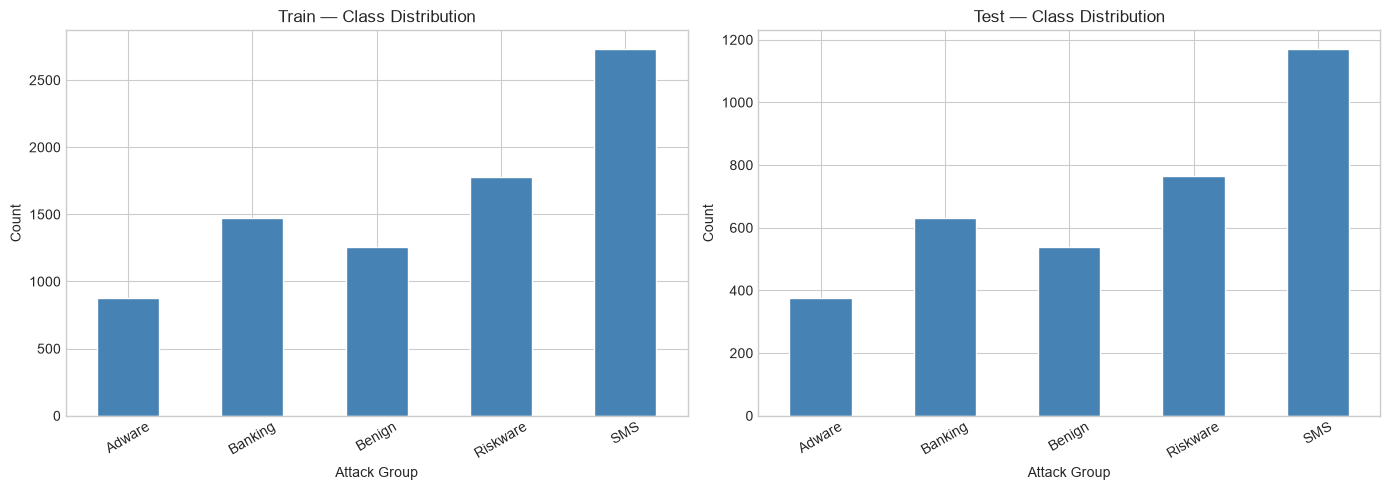

Train class counts:
Class_encoded
SMS         2733
Riskware    1782
Banking     1470
Benign      1256
Adware       877
Name: count, dtype: int64
Test class counts:
Class_encoded
SMS         1171
Riskware     764
Banking      630
Benign       539
Adware       376
Name: count, dtype: int64


In [6]:
# --- 5a. Class distribution ---
label_names = dict(enumerate(le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (y, title) in zip(axes, [(y_train, "Train"), (y_test, "Test")]):
    counts = y.value_counts().sort_index()
    counts.index = [label_names[i] for i in counts.index]
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{title} — Class Distribution")
    ax.set_xlabel("Attack Group")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Train class counts:")
print(y_train.map(label_names).value_counts())
print("Test class counts:")
print(y_test.map(label_names).value_counts())


Top 30 features by Information Gain (Mutual Information):
['gettimeofday', 'pread64', 'mmap2', 'open', 'access', 'munmap', 'close', 'sigprocmask', 'stat64', 'fcntl64', 'read', 'fstat64', 'gettid', 'mprotect', 'getuid32', 'getpid', 'epoll_wait', 'FS_ACCESS____', 'lseek', 'FS_ACCESS(READ)____', 'clock_gettime', 'madvise', 'writev', 'lstat64', 'write', 'sigaltstack', 'prctl', 'mkdir', 'recvfrom', 'setpriority']


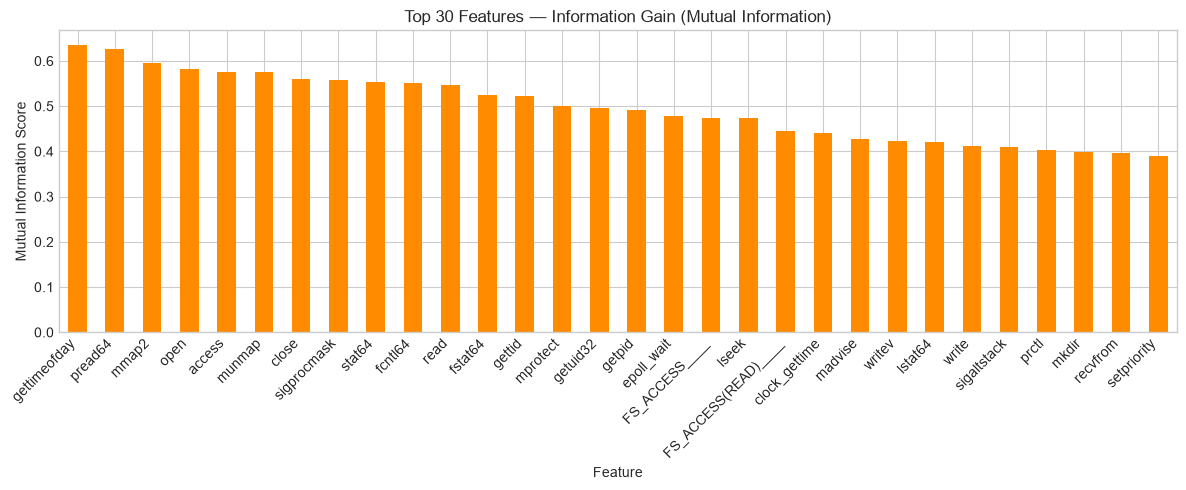

In [7]:
from sklearn.feature_selection import mutual_info_classif
X_train=X_train_p
k_mi = 30   

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X_train.columns)
mi_scores_sorted = mi_scores_series.sort_values(ascending=False)

selected_features_mi = mi_scores_sorted.head(k_mi).index.tolist()
print(f"Top {k_mi} features by Information Gain (Mutual Information):")
print(selected_features_mi)

# Plot
plt.figure(figsize=(12, 5))
mi_scores_sorted.head(k_mi).plot(kind='bar', color='darkorange', edgecolor='none')
plt.title(f'Top {k_mi} Features — Information Gain (Mutual Information)')
plt.xlabel('Feature')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Top 30 features selected by Chi-Square test:
['checkOperation', 'setInTouchMode', 'setpgid', 'getWifiServiceMessenger', 'vfork', 'sysinfo', 'FS_PIPE_ACCESS(READ)___', 'getReceiverInfo', 'registerInputDevicesChangedListener', 'getInputDeviceIds', 'getSubscriberId', 'fchmod', 'getIccSerialNumber', 'access', 'TERMINATE_PROCESS', 'exit_group', 'setMode', 'socketpair', 'setWifiEnabled', 'sendto', 'getAllNetworkInfo', 'ugetrlimit', 'sched_getparam', 'sched_getscheduler', 'getgid32', 'getegid32', 'getNeighboringCellInfo', 'getCellLocation', 'ftruncate64', 'dup2']


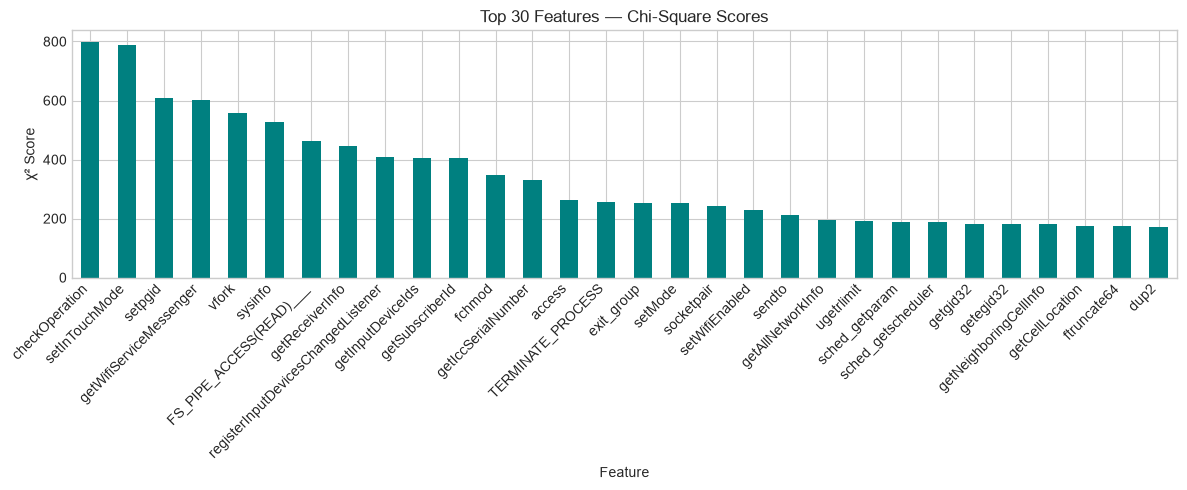

In [8]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

X_train=X_train_p
X_test=X_test_p

k = 30  

chi2_selector = SelectKBest(score_func=chi2, k=k)
chi2_selector.fit(X_train, y_train)

chi2_scores = pd.Series(chi2_selector.scores_, index=X_train.columns)
chi2_scores_sorted = chi2_scores.sort_values(ascending=False)

selected_features_chi2 = chi2_scores_sorted.head(k).index.tolist()
print(f"Top {k} features selected by Chi-Square test:")
print(selected_features_chi2)

# Plot top-k chi2 scores
plt.figure(figsize=(12, 5))
chi2_scores_sorted.head(k).plot(kind='bar', color='teal', edgecolor='none')
plt.title(f'Top {k} Features — Chi-Square Scores')
plt.xlabel('Feature')
plt.ylabel('χ² Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 Running RFECV (Recursive Feature Elimination with Cross-Validation) using XGBoost

 Optimal number of features found by RFECV: 92
Selected Features: ['ACCESS_PERSONAL_INFO___', 'CREATE_FOLDER_____', 'FS_ACCESS()____', 'FS_ACCESS(CREATE__READ__WRITE)', 'FS_ACCESS(CREATE__WRITE)__', 'FS_ACCESS(CREATE__WRITE__APPEND)', 'FS_PIPE_ACCESS___', 'FS_PIPE_ACCESS(WRITE)___', 'NETWORK_ACCESS____', 'NETWORK_ACCESS()____', 'NETWORK_ACCESS(WRITE)____', 'TERMINATE_THREAD', '__arm_nr_set_tls', '_llseek', '_newselect', 'access', 'addAccessibilityInteractionConnection', 'addToDisplay', 'addToDisplayWithoutInputChannel', 'bind', 'cancelNotificationWithTag', 'chdir', 'checkPermission', 'close', 'disconnect', 'epoll_create', 'epoll_ctl', 'fchmod', 'flock', 'fstat64', 'fsync', 'ftruncate', 'getAccountsAsUser', 'getActiveNetworkInfo', 'getActivePhoneType', 'getActivityInfo', 'getApplicationInfo', 'getCallState', 'getComponentEnabledSetting', 'getConnectionInfo', 'getCurrentSpellCheckerSubtype', 'getDeviceId'

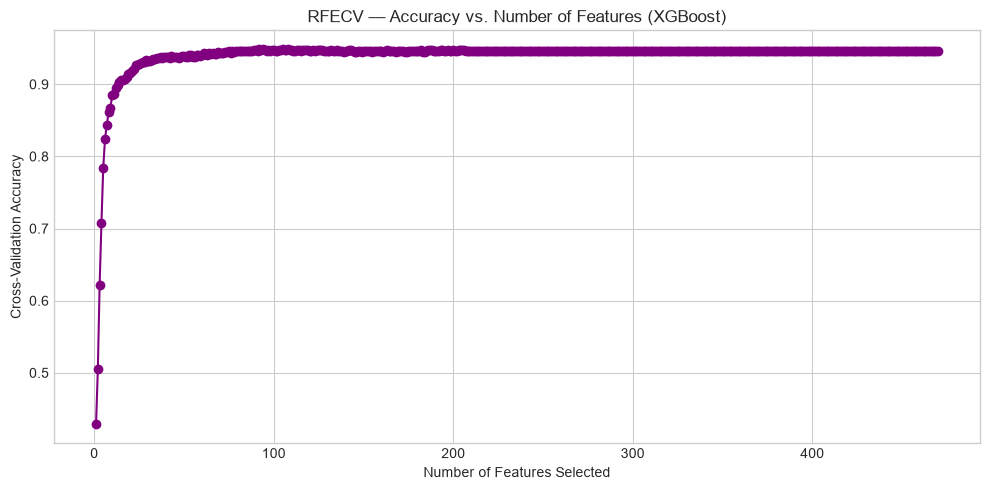


 RFECV Completed and data saved successfully!


In [9]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier  
from sklearn.feature_selection import RFECV
import joblib


estimator = XGBClassifier(random_state=42, n_jobs=1)

print(" Running RFECV (Recursive Feature Elimination with Cross-Validation) using XGBoost")
rfecv = RFECV(
    estimator=estimator,
    step=1,          
    cv=5,            
    scoring='accuracy',
    n_jobs=-1        
)

rfecv.fit(X_train_p, y_train)

print(f"\n Optimal number of features found by RFECV: {rfecv.n_features_}")

selected_features_rfecv = X_train_p.columns[rfecv.support_].tolist()
print(f"Selected Features: {selected_features_rfecv}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], color='purple', marker='o')
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation Accuracy")
plt.title("RFECV — Accuracy vs. Number of Features (XGBoost)")
plt.grid(True)
plt.tight_layout()
plt.show()

X_train_rfecv = rfecv.transform(X_train_p)
X_test_rfecv  = rfecv.transform(X_test_p)

joblib.dump(X_train_rfecv, "X_train_rfecv_cic.pkl")
joblib.dump(X_test_rfecv, "X_test_rfecv_cic.pkl")
print("\n RFECV Completed and data saved successfully!")

In [13]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier 
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

6

estimator = XGBClassifier(random_state=42, n_jobs=1)

print(" Running Forward Selection ")
forward_selector = SFS(
    estimator=estimator,
    k_features=20,       
    forward=True,        
    floating=False,
    scoring='accuracy',
    cv=5,                
    n_jobs=-1            
)

forward_selector.fit(X_train_p, y_train)

selected_features_forward = list(forward_selector.k_feature_names_)
print(f"\n Top 20 features selected by Forward Selection:")
print(selected_features_forward)

X_train_fwd = forward_selector.transform(X_train_p) 
X_test_fwd  = forward_selector.transform(X_test_p)

joblib.dump(X_train_fwd, "X_train_forward_cic.pkl")
joblib.dump(X_test_fwd, "X_test_forward_cic.pkl")
print("\n Forward Selection Completed and data saved successfully!")

 Running Forward Selection 

 Top 20 features selected by Forward Selection:
['ACCESS_PERSONAL_INFO___', 'FS_ACCESS(READ__WRITE)__', 'FS_PIPE_ACCESS()___', 'NETWORK_ACCESS(READ)____', 'chmod', 'epoll_create', 'flock', 'getApplicationEnabledSetting', 'getDisplayInfo', 'getPackageInfo', 'getProviderInfo', 'getegid32', 'mprotect', 'nanosleep', 'onGetSentenceSuggestionsMultiple', 'pread64', 'read', 'sendto', 'setsockopt', 'sigprocmask']

 Forward Selection Completed and data saved successfully!


In [15]:


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

all_classes = le.transform(le.classes_)
CLASS_NAMES = list(le.classes_)

def evaluate(name, y_true, y_pred):
    
    acc     = accuracy_score(y_true, y_pred)
    prec    = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec     = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1      = f1_score(y_true, y_pred, average='weighted')
    f1_mac  = f1_score(y_true, y_pred, average='macro')

    print(f'\n=== {name} ===')
    print(f'Accuracy : {acc:.4f}   Precision : {prec:.4f}   Recall : {rec:.4f}   '
          f'Weighted F1 : {f1:.4f}   Macro F1: {f1_mac:.4f}')

    print(classification_report(y_true, y_pred, labels=all_classes, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred, labels=all_classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    plt.show()

    return acc, prec, rec, f1, f1_mac

RESULTS = {}

 Starting SVM Evaluation across ALL Feature Selection methods...

 Testing Feature Set: Full_Features (Features Count: 470)

 Linear SVM Training Time: 1.18 seconds
 Predict Time  : 0.0123 seconds

=== SVM (Linear) — Full_Features ===
Accuracy : 0.7615   Precision : 0.7679   Recall : 0.7615   Weighted F1 : 0.7547   Macro F1: 0.7308
              precision    recall  f1-score   support

      Adware       0.70      0.51      0.59       376
     Banking       0.69      0.66      0.68       630
      Benign       0.88      0.77      0.82       539
    Riskware       0.83      0.66      0.73       764
         SMS       0.73      0.96      0.83      1171

    accuracy                           0.76      3480
   macro avg       0.77      0.71      0.73      3480
weighted avg       0.77      0.76      0.75      3480



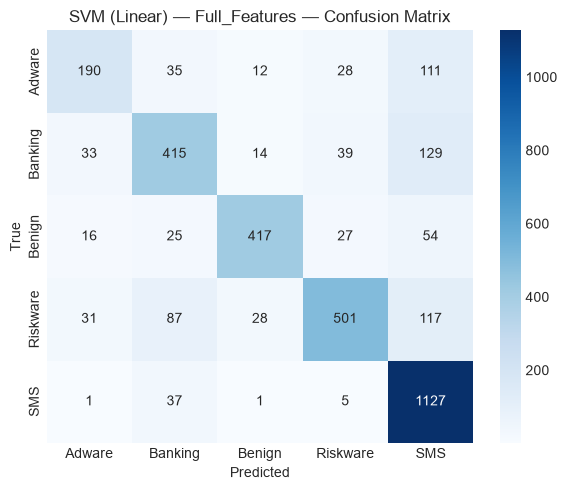


 RBF SVM Training Time: 5.13 seconds
 Predict Time  : 3.3326 seconds

=== SVM (RBF) — Full_Features ===
Accuracy : 0.7776   Precision : 0.7827   Recall : 0.7776   Weighted F1 : 0.7733   Macro F1: 0.7438
              precision    recall  f1-score   support

      Adware       0.64      0.53      0.58       376
     Banking       0.68      0.76      0.72       630
      Benign       0.88      0.73      0.80       539
    Riskware       0.86      0.68      0.76       764
         SMS       0.79      0.95      0.86      1171

    accuracy                           0.78      3480
   macro avg       0.77      0.73      0.74      3480
weighted avg       0.78      0.78      0.77      3480



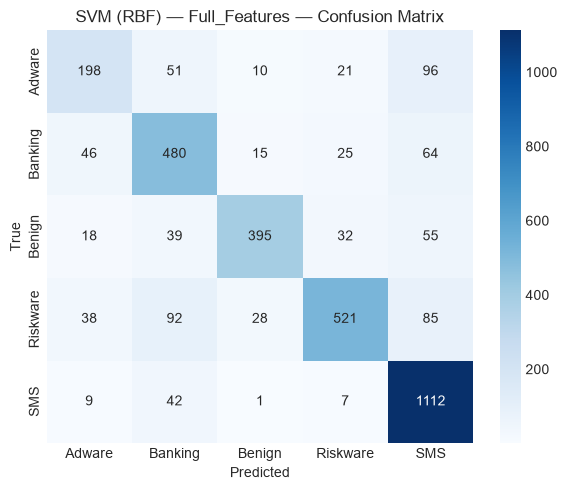

 Testing Feature Set: Filter_MI (Features Count: 30)

 Linear SVM Training Time: 0.14 seconds
 Predict Time  : 0.0027 seconds

=== SVM (Linear) — Filter_MI ===
Accuracy : 0.5109   Precision : 0.6175   Recall : 0.5109   Weighted F1 : 0.4307   Macro F1: 0.3675
              precision    recall  f1-score   support

      Adware       0.55      0.02      0.03       376
     Banking       0.92      0.07      0.13       630
      Benign       0.71      0.50      0.58       539
    Riskware       0.58      0.38      0.46       764
         SMS       0.46      1.00      0.63      1171

    accuracy                           0.51      3480
   macro avg       0.64      0.39      0.37      3480
weighted avg       0.62      0.51      0.43      3480



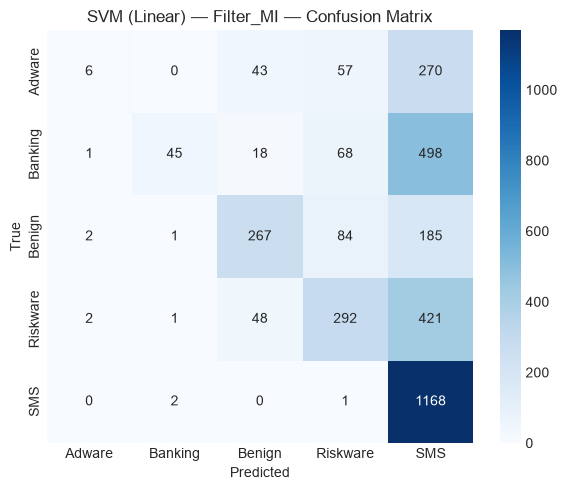


 RBF SVM Training Time: 1.43 seconds
 Predict Time  : 1.2288 seconds

=== SVM (RBF) — Filter_MI ===
Accuracy : 0.7276   Precision : 0.7287   Recall : 0.7276   Weighted F1 : 0.7193   Macro F1: 0.6873
              precision    recall  f1-score   support

      Adware       0.60      0.50      0.55       376
     Banking       0.64      0.69      0.66       630
      Benign       0.80      0.67      0.73       539
    Riskware       0.78      0.57      0.66       764
         SMS       0.75      0.95      0.84      1171

    accuracy                           0.73      3480
   macro avg       0.71      0.68      0.69      3480
weighted avg       0.73      0.73      0.72      3480



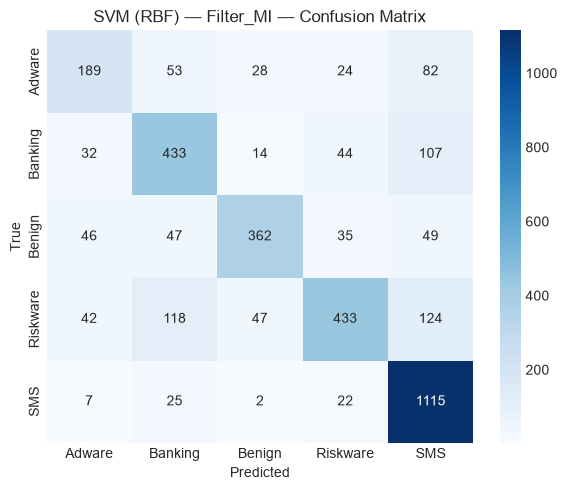

 Testing Feature Set: Filter_Chi2 (Features Count: 30)

 Linear SVM Training Time: 0.12 seconds
 Predict Time  : 0.0020 seconds

=== SVM (Linear) — Filter_Chi2 ===
Accuracy : 0.5931   Precision : 0.6286   Recall : 0.5931   Weighted F1 : 0.5565   Macro F1: 0.5259
              precision    recall  f1-score   support

      Adware       0.49      0.33      0.39       376
     Banking       0.60      0.20      0.30       630
      Benign       0.80      0.65      0.71       539
    Riskware       0.75      0.41      0.53       764
         SMS       0.53      0.98      0.69      1171

    accuracy                           0.59      3480
   macro avg       0.63      0.51      0.53      3480
weighted avg       0.63      0.59      0.56      3480



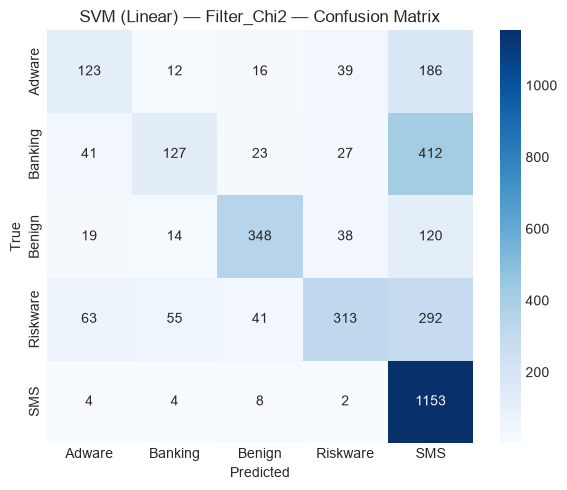


 RBF SVM Training Time: 2.18 seconds
 Predict Time  : 1.3446 seconds

=== SVM (RBF) — Filter_Chi2 ===
Accuracy : 0.6480   Precision : 0.6692   Recall : 0.6480   Weighted F1 : 0.6223   Macro F1: 0.5918
              precision    recall  f1-score   support

      Adware       0.57      0.38      0.45       376
     Banking       0.69      0.27      0.39       630
      Benign       0.81      0.67      0.73       539
    Riskware       0.73      0.58      0.65       764
         SMS       0.59      0.97      0.73      1171

    accuracy                           0.65      3480
   macro avg       0.68      0.57      0.59      3480
weighted avg       0.67      0.65      0.62      3480



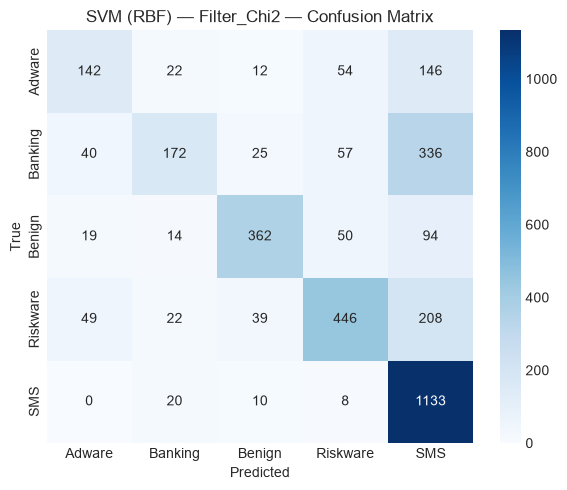

 Testing Feature Set: Wrapper_RFECV (Features Count: 92)

 Linear SVM Training Time: 0.25 seconds
 Predict Time  : 0.0027 seconds

=== SVM (Linear) — Wrapper_RFECV ===
Accuracy : 0.6511   Precision : 0.6827   Recall : 0.6511   Weighted F1 : 0.6304   Macro F1: 0.6049
              precision    recall  f1-score   support

      Adware       0.64      0.37      0.47       376
     Banking       0.69      0.41      0.51       630
      Benign       0.75      0.71      0.73       539
    Riskware       0.80      0.46      0.58       764
         SMS       0.59      0.97      0.73      1171

    accuracy                           0.65      3480
   macro avg       0.69      0.58      0.60      3480
weighted avg       0.68      0.65      0.63      3480



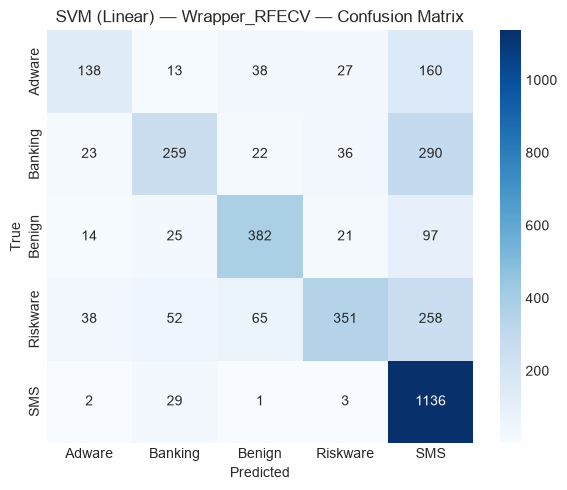


 RBF SVM Training Time: 1.70 seconds
 Predict Time  : 0.9958 seconds

=== SVM (RBF) — Wrapper_RFECV ===
Accuracy : 0.8103   Precision : 0.8182   Recall : 0.8103   Weighted F1 : 0.8056   Macro F1: 0.7888
              precision    recall  f1-score   support

      Adware       0.73      0.71      0.72       376
     Banking       0.86      0.61      0.71       630
      Benign       0.87      0.78      0.82       539
    Riskware       0.86      0.79      0.83       764
         SMS       0.77      0.98      0.86      1171

    accuracy                           0.81      3480
   macro avg       0.82      0.77      0.79      3480
weighted avg       0.82      0.81      0.81      3480



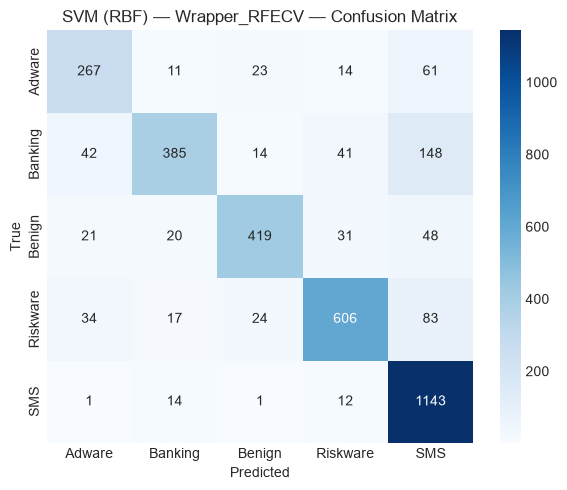

 Testing Feature Set: Wrapper_Forward (Features Count: 20)

 Linear SVM Training Time: 0.09 seconds
 Predict Time  : 0.0011 seconds

=== SVM (Linear) — Wrapper_Forward ===
Accuracy : 0.5336   Precision : 0.5844   Recall : 0.5336   Weighted F1 : 0.4699   Macro F1: 0.4060
              precision    recall  f1-score   support

      Adware       0.93      0.03      0.07       376
     Banking       0.46      0.17      0.24       630
      Benign       0.69      0.49      0.57       539
    Riskware       0.56      0.41      0.48       764
         SMS       0.50      0.99      0.67      1171

    accuracy                           0.53      3480
   macro avg       0.63      0.42      0.41      3480
weighted avg       0.58      0.53      0.47      3480



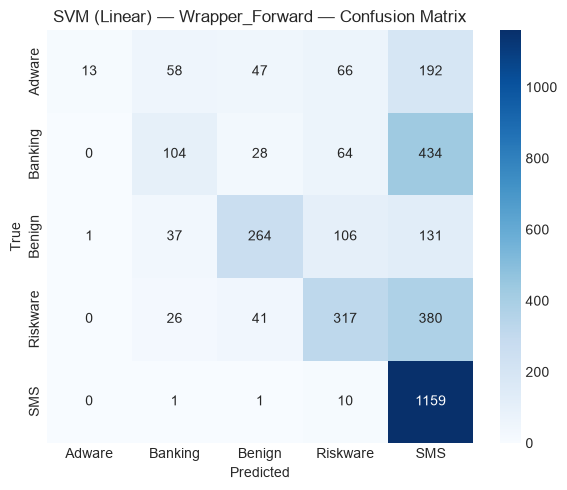


 RBF SVM Training Time: 1.56 seconds
 Predict Time  : 1.2786 seconds

=== SVM (RBF) — Wrapper_Forward ===
Accuracy : 0.6641   Precision : 0.6703   Recall : 0.6641   Weighted F1 : 0.6482   Macro F1: 0.6056
              precision    recall  f1-score   support

      Adware       0.46      0.34      0.39       376
     Banking       0.60      0.44      0.51       630
      Benign       0.83      0.57      0.68       539
    Riskware       0.76      0.62      0.68       764
         SMS       0.64      0.96      0.77      1171

    accuracy                           0.66      3480
   macro avg       0.66      0.59      0.61      3480
weighted avg       0.67      0.66      0.65      3480



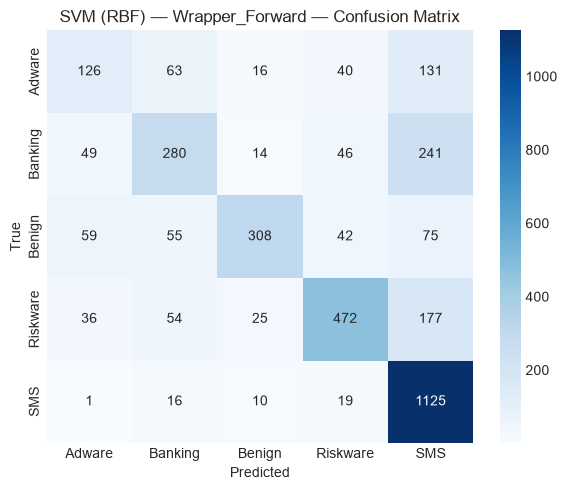


 All SVM models trained and evaluated successfully!


In [16]:
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
import time


def _make_linear_svc():
    return Pipeline([
        ('clf', LinearSVC(C=1.0, max_iter=2000 , random_state=42)),
    ])

def _make_rbf_svc():
    return Pipeline([
        ('clf', SVC(kernel='rbf', C=10, gamma='scale',
                    decision_function_shape='ovr', random_state=42)),
    ])

FEATURE_SETS = {
    'Full_Features': (X_train_p, X_test_p),
    'Filter_MI': (X_train_p[selected_features_mi], X_test_p[selected_features_mi]),
    'Filter_Chi2': (X_train_p[selected_features_chi2], X_test_p[selected_features_chi2]),
    'Wrapper_RFECV': (X_train_rfecv, X_test_rfecv),
    'Wrapper_Forward': (X_train_fwd, X_test_fwd)
}

print(" Starting SVM Evaluation across ALL Feature Selection methods...\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    print(f"{'='*60}")
    print(f" Testing Feature Set: {fs_name} (Features Count: {X_tr.shape[1]})")
    print(f"{'='*60}")
    
    for kind, factory in [('Linear', _make_linear_svc), ('RBF', _make_rbf_svc)]:
        clf = factory()
        
        start_time = time.time()
        clf.fit(X_tr, y_train)
        train_time = time.time() - start_time
        start_pred = time.time()
        
        y_pred = clf.predict(X_te)
        pred_time = time.time() - start_pred
        
        label = f'SVM ({kind}) — {fs_name}'
        print(f"\n {kind} SVM Training Time: {train_time:.2f} seconds")
        print(f" Predict Time  : {pred_time:.4f} seconds")
        acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)

        
        RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                }

print("\n All SVM models trained and evaluated successfully!")

 Starting MLP Evaluation across ALL Feature Selection methods

Testing Feature Set: Full_Features (Features Count: 470)
Iteration 1, loss = 1.44324952
Validation score: 0.517241
Iteration 2, loss = 1.18329312
Validation score: 0.603448
Iteration 3, loss = 0.99153821
Validation score: 0.690887
Iteration 4, loss = 0.87373372
Validation score: 0.713054
Iteration 5, loss = 0.79816369
Validation score: 0.748768
Iteration 6, loss = 0.74545842
Validation score: 0.758621
Iteration 7, loss = 0.70003931
Validation score: 0.769704
Iteration 8, loss = 0.66670743
Validation score: 0.784483
Iteration 9, loss = 0.64046627
Validation score: 0.788177
Iteration 10, loss = 0.62203776
Validation score: 0.800493
Iteration 11, loss = 0.60199988
Validation score: 0.794335
Iteration 12, loss = 0.58342769
Validation score: 0.798030
Iteration 13, loss = 0.56133801
Validation score: 0.807882
Iteration 14, loss = 0.54891754
Validation score: 0.809113
Iteration 15, loss = 0.53882608
Validation score: 0.802956
Iter

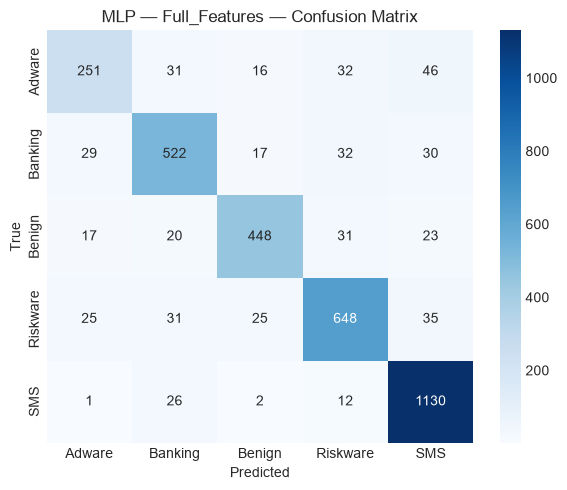

Testing Feature Set: Filter_MI (Features Count: 30)

 MLP Training Time: 2.18 seconds

 MLP predict Time: 0.00 seconds

=== MLP — Filter_MI ===
Accuracy : 0.6172   Precision : 0.6090   Recall : 0.6172   Weighted F1 : 0.5791   Macro F1: 0.5351
              precision    recall  f1-score   support

      Adware       0.46      0.33      0.38       376
     Banking       0.60      0.17      0.26       630
      Benign       0.69      0.65      0.67       539
    Riskware       0.61      0.60      0.61       764
         SMS       0.63      0.94      0.75      1171

    accuracy                           0.62      3480
   macro avg       0.60      0.54      0.54      3480
weighted avg       0.61      0.62      0.58      3480



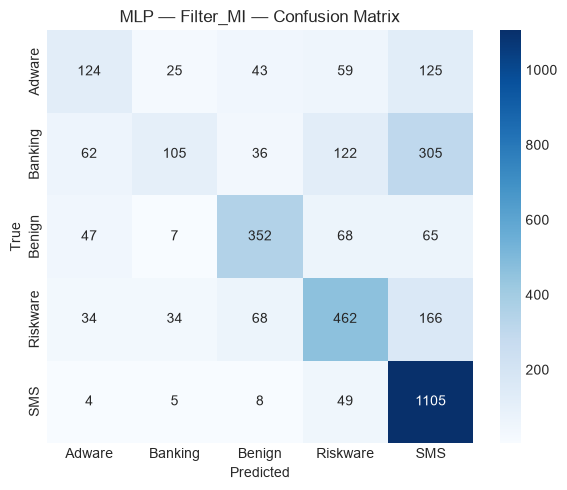

Testing Feature Set: Filter_Chi2 (Features Count: 30)

 MLP Training Time: 1.37 seconds

 MLP predict Time: 0.01 seconds

=== MLP — Filter_Chi2 ===
Accuracy : 0.6422   Precision : 0.6880   Recall : 0.6422   Weighted F1 : 0.6168   Macro F1: 0.5889
              precision    recall  f1-score   support

      Adware       0.48      0.44      0.46       376
     Banking       0.76      0.23      0.36       630
      Benign       0.92      0.65      0.76       539
    Riskware       0.74      0.56      0.64       764
         SMS       0.58      0.98      0.73      1171

    accuracy                           0.64      3480
   macro avg       0.69      0.57      0.59      3480
weighted avg       0.69      0.64      0.62      3480



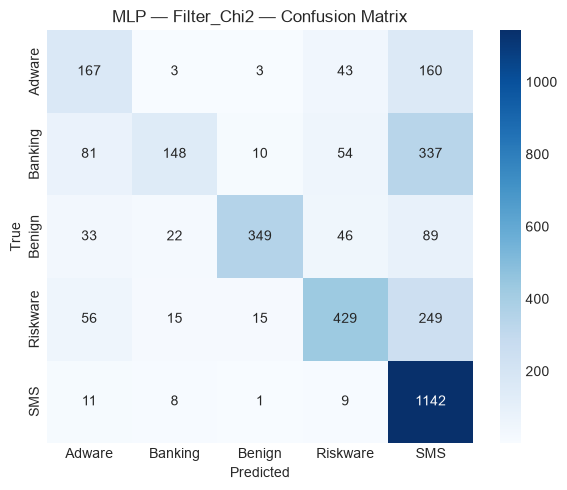

Testing Feature Set: Wrapper_RFECV (Features Count: 92)


C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



 MLP Training Time: 3.12 seconds

 MLP predict Time: 0.01 seconds

=== MLP — Wrapper_RFECV ===
Accuracy : 0.8471   Precision : 0.8459   Recall : 0.8471   Weighted F1 : 0.8451   Macro F1: 0.8238
              precision    recall  f1-score   support

      Adware       0.82      0.70      0.75       376
     Banking       0.76      0.77      0.77       630
      Benign       0.88      0.81      0.84       539
    Riskware       0.84      0.82      0.83       764
         SMS       0.89      0.97      0.93      1171

    accuracy                           0.85      3480
   macro avg       0.84      0.81      0.82      3480
weighted avg       0.85      0.85      0.85      3480



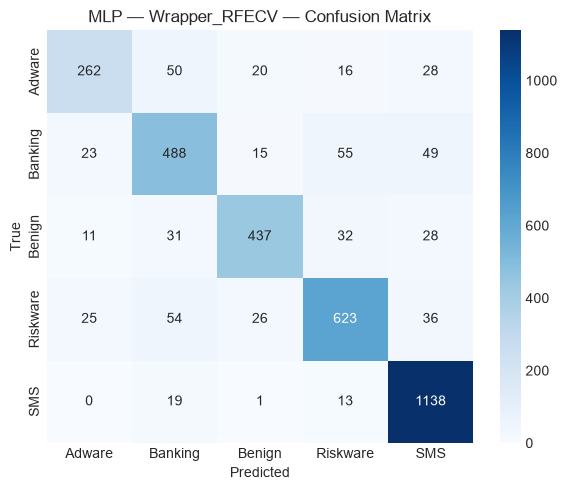

Testing Feature Set: Wrapper_Forward (Features Count: 20)


C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



 MLP Training Time: 2.87 seconds

 MLP predict Time: 0.00 seconds

=== MLP — Wrapper_Forward ===
Accuracy : 0.6460   Precision : 0.6541   Recall : 0.6460   Weighted F1 : 0.6230   Macro F1: 0.5754
              precision    recall  f1-score   support

      Adware       0.42      0.29      0.34       376
     Banking       0.72      0.37      0.49       630
      Benign       0.64      0.63      0.64       539
    Riskware       0.76      0.57      0.65       764
         SMS       0.63      0.97      0.76      1171

    accuracy                           0.65      3480
   macro avg       0.63      0.56      0.58      3480
weighted avg       0.65      0.65      0.62      3480



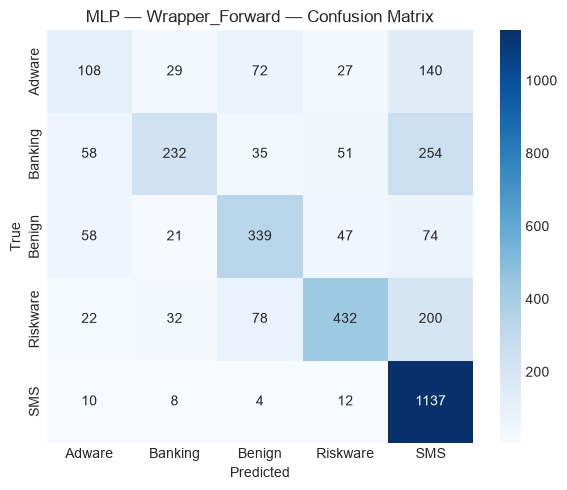


 All MLP models trained and evaluated successfully


In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
import time

def _make_mlp(verbose=False):
    return Pipeline([
        ('clf', MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation='relu', solver='adam',
            alpha=1e-4, batch_size=256,
            learning_rate_init=1e-3, max_iter=50,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=5, random_state=42, verbose=verbose)),
    ])

print(" Starting MLP Evaluation across ALL Feature Selection methods\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    print(f"{'='*60}")
    print(f"Testing Feature Set: {fs_name} (Features Count: {X_tr.shape[1]})")
    print(f"{'='*60}")
    
    is_baseline = (fs_name == 'Full_Features')
    mlp_pipeline = _make_mlp(verbose=is_baseline)
    
    
    start_time = time.time()
    mlp_pipeline.fit(X_tr, y_train)
    train_time = time.time() - start_time
    start_pred = time.time()   
    y_pred = mlp_pipeline.predict(X_te)
    pred_time = time.time() - start_pred
    label = f'MLP — {fs_name}'
    print(f"\n MLP Training Time: {train_time:.2f} seconds")
    print(f"\n MLP predict Time: {pred_time:.2f} seconds")

    
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    
   
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                }

print("\n All MLP models trained and evaluated successfully")

 Starting XGBoost Baseline (Without GridSearchCV) across ALL Feature Sets...

 Testing XGBoost Baseline on Feature Set: Full_Features (Features Count: 470)

 Training Time: 2.32 seconds

 predict Time: 0.03 seconds

=== XGBoost (Baseline) — Full_Features ===
Accuracy : 0.9457   Precision : 0.9458   Recall : 0.9457   Weighted F1 : 0.9456   Macro F1: 0.9353
              precision    recall  f1-score   support

      Adware       0.89      0.91      0.90       376
     Banking       0.94      0.91      0.92       630
      Benign       0.92      0.95      0.93       539
    Riskware       0.94      0.93      0.93       764
         SMS       0.98      0.99      0.98      1171

    accuracy                           0.95      3480
   macro avg       0.93      0.94      0.94      3480
weighted avg       0.95      0.95      0.95      3480



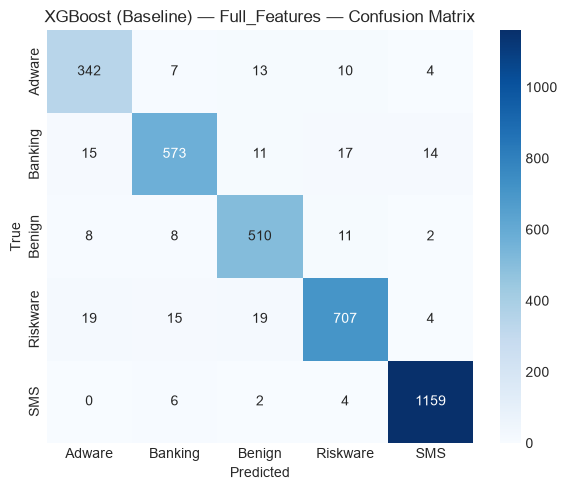

 Testing XGBoost Baseline on Feature Set: Filter_MI (Features Count: 30)

 Training Time: 0.65 seconds

 predict Time: 0.01 seconds

=== XGBoost (Baseline) — Filter_MI ===
Accuracy : 0.9218   Precision : 0.9223   Recall : 0.9218   Weighted F1 : 0.9219   Macro F1: 0.9053
              precision    recall  f1-score   support

      Adware       0.84      0.88      0.86       376
     Banking       0.91      0.90      0.90       630
      Benign       0.86      0.88      0.87       539
    Riskware       0.93      0.90      0.91       764
         SMS       0.97      0.99      0.98      1171

    accuracy                           0.92      3480
   macro avg       0.90      0.91      0.91      3480
weighted avg       0.92      0.92      0.92      3480



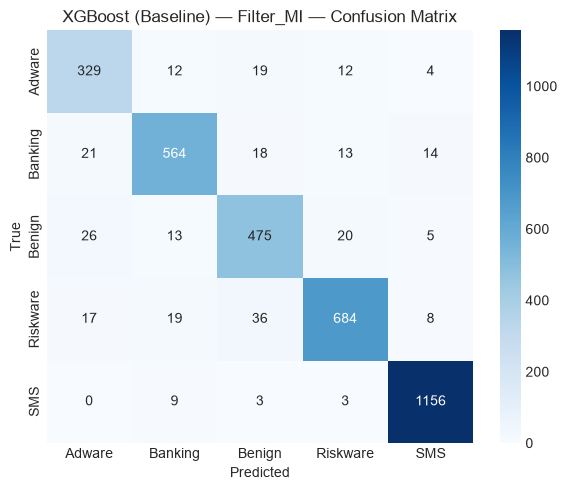

 Testing XGBoost Baseline on Feature Set: Filter_Chi2 (Features Count: 30)

 Training Time: 0.34 seconds

 predict Time: 0.01 seconds

=== XGBoost (Baseline) — Filter_Chi2 ===
Accuracy : 0.8575   Precision : 0.8576   Recall : 0.8575   Weighted F1 : 0.8561   Macro F1: 0.8370
              precision    recall  f1-score   support

      Adware       0.82      0.74      0.78       376
     Banking       0.77      0.82      0.79       630
      Benign       0.87      0.81      0.84       539
    Riskware       0.88      0.81      0.85       764
         SMS       0.89      0.97      0.93      1171

    accuracy                           0.86      3480
   macro avg       0.85      0.83      0.84      3480
weighted avg       0.86      0.86      0.86      3480



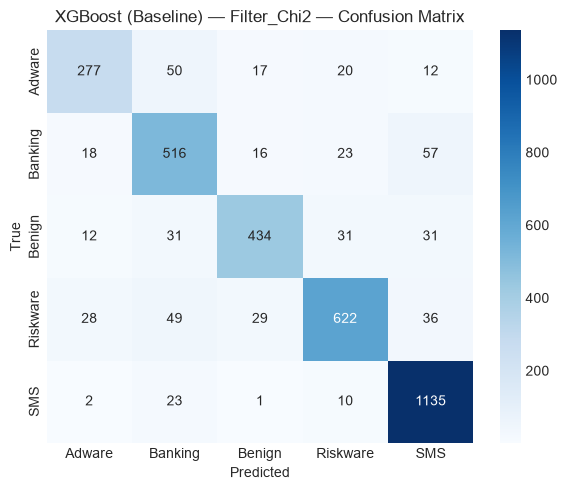

 Testing XGBoost Baseline on Feature Set: Wrapper_RFECV (Features Count: 92)

 Training Time: 0.66 seconds

 predict Time: 0.00 seconds

=== XGBoost (Baseline) — Wrapper_RFECV ===
Accuracy : 0.9425   Precision : 0.9428   Recall : 0.9425   Weighted F1 : 0.9425   Macro F1: 0.9319
              precision    recall  f1-score   support

      Adware       0.89      0.91      0.90       376
     Banking       0.95      0.91      0.93       630
      Benign       0.91      0.94      0.92       539
    Riskware       0.94      0.92      0.93       764
         SMS       0.98      0.99      0.98      1171

    accuracy                           0.94      3480
   macro avg       0.93      0.93      0.93      3480
weighted avg       0.94      0.94      0.94      3480



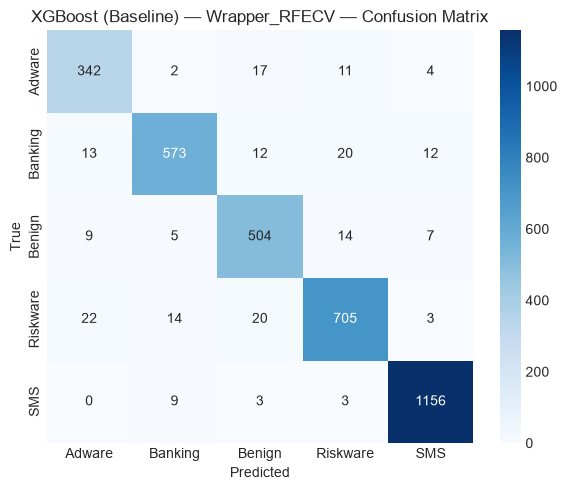

 Testing XGBoost Baseline on Feature Set: Wrapper_Forward (Features Count: 20)

 Training Time: 0.36 seconds

 predict Time: 0.00 seconds

=== XGBoost (Baseline) — Wrapper_Forward ===
Accuracy : 0.9259   Precision : 0.9263   Recall : 0.9259   Weighted F1 : 0.9259   Macro F1: 0.9114
              precision    recall  f1-score   support

      Adware       0.84      0.88      0.86       376
     Banking       0.93      0.89      0.91       630
      Benign       0.89      0.90      0.89       539
    Riskware       0.92      0.90      0.91       764
         SMS       0.97      0.99      0.98      1171

    accuracy                           0.93      3480
   macro avg       0.91      0.91      0.91      3480
weighted avg       0.93      0.93      0.93      3480



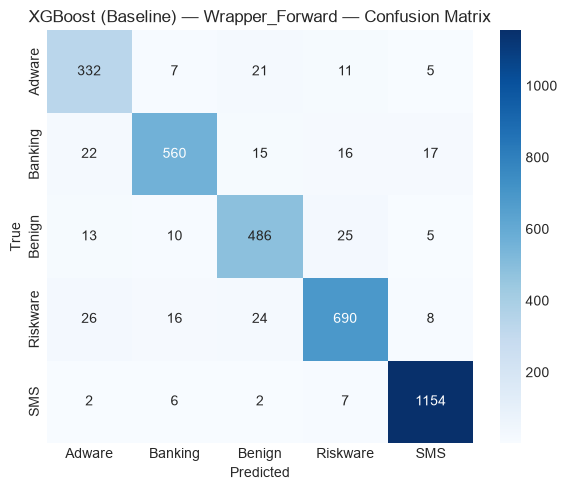


 All XGBoost baseline models evaluated successfully!


In [18]:
import xgboost as xgb
import time

print(" Starting XGBoost Baseline (Without GridSearchCV) across ALL Feature Sets...\n")


for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    print(f"{'='*60}")
    print(f" Testing XGBoost Baseline on Feature Set: {fs_name} (Features Count: {X_tr.shape[1]})")
    print(f"{'='*60}")
    
    
    xgb_baseline = xgb.XGBClassifier(verbosity=0, random_state=42, n_jobs=-1)
    
    start_time = time.time()
    xgb_baseline.fit(X_tr, y_train)
    train_time = time.time() - start_time
    start_pred = time.time()   
    y_pred = xgb_baseline.predict(X_te)
    pred_time = time.time() - start_pred
    
    label = f'XGBoost (Baseline) — {fs_name}'
    print(f"\n Training Time: {train_time:.2f} seconds")
    print(f"\n predict Time: {pred_time:.2f} seconds")

 
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                }

print("\n All XGBoost baseline models evaluated successfully!")

 Starting SVM + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...

 Testing SVM (GridSearchCV) on Feature Set: Filter_MI
 Training Time: 46.47s |  Best Params: {'clf__C': 1000, 'clf__gamma': 1, 'clf__kernel': 'rbf'}

 predict Time: 1.21 seconds

=== SVM (Optimized) — Filter_MI ===
Accuracy : 0.6759   Precision : 0.6735   Recall : 0.6759   Weighted F1 : 0.6620   Macro F1: 0.6281
              precision    recall  f1-score   support

      Adware       0.58      0.45      0.51       376
     Banking       0.55      0.49      0.52       630
      Benign       0.79      0.64      0.71       539
    Riskware       0.71      0.53      0.60       764
         SMS       0.70      0.96      0.81      1171

    accuracy                           0.68      3480
   macro avg       0.66      0.61      0.63      3480
weighted avg       0.67      0.68      0.66      3480



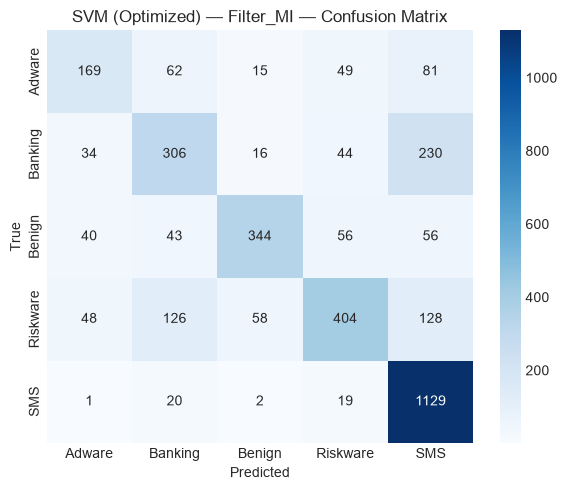

 Testing SVM (GridSearchCV) on Feature Set: Filter_Chi2
 Training Time: 36.49s |  Best Params: {'clf__C': 1000, 'clf__gamma': 1, 'clf__kernel': 'rbf'}

 predict Time: 0.80 seconds

=== SVM (Optimized) — Filter_Chi2 ===
Accuracy : 0.7428   Precision : 0.7525   Recall : 0.7428   Weighted F1 : 0.7346   Macro F1: 0.7061
              precision    recall  f1-score   support

      Adware       0.64      0.49      0.55       376
     Banking       0.68      0.56      0.61       630
      Benign       0.90      0.69      0.78       539
    Riskware       0.84      0.70      0.76       764
         SMS       0.70      0.97      0.82      1171

    accuracy                           0.74      3480
   macro avg       0.75      0.68      0.71      3480
weighted avg       0.75      0.74      0.73      3480



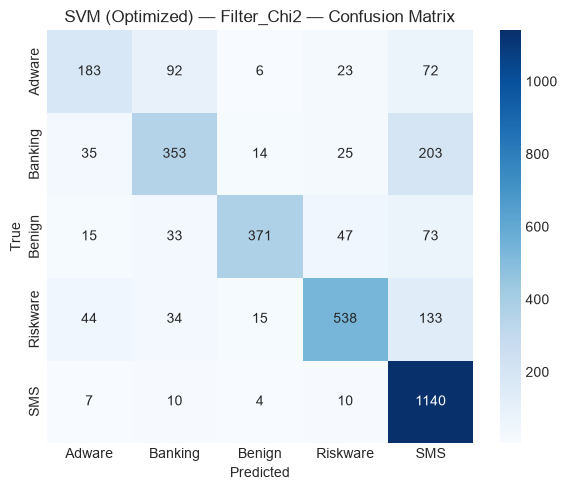

 Testing SVM (GridSearchCV) on Feature Set: Wrapper_RFECV
 Training Time: 73.29s |  Best Params: {'clf__C': 1000, 'clf__gamma': 1, 'clf__kernel': 'rbf'}

 predict Time: 0.73 seconds

=== SVM (Optimized) — Wrapper_RFECV ===
Accuracy : 0.8632   Precision : 0.8635   Recall : 0.8632   Weighted F1 : 0.8621   Macro F1: 0.8417
              precision    recall  f1-score   support

      Adware       0.81      0.74      0.78       376
     Banking       0.77      0.83      0.80       630
      Benign       0.88      0.82      0.85       539
    Riskware       0.89      0.82      0.85       764
         SMS       0.91      0.98      0.94      1171

    accuracy                           0.86      3480
   macro avg       0.85      0.83      0.84      3480
weighted avg       0.86      0.86      0.86      3480



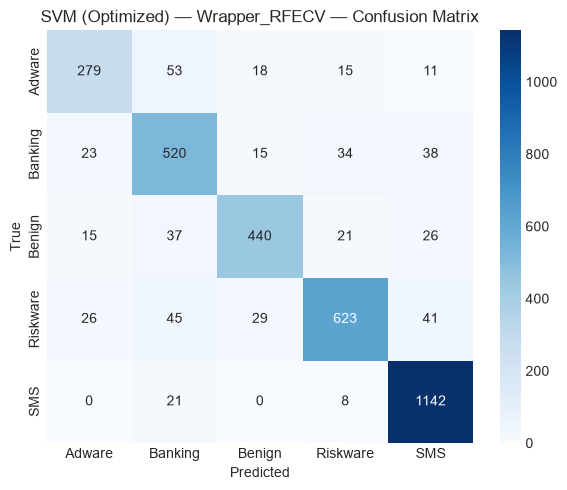

 Testing SVM (GridSearchCV) on Feature Set: Wrapper_Forward
 Training Time: 40.67s |  Best Params: {'clf__C': 1000, 'clf__gamma': 1, 'clf__kernel': 'rbf'}

 predict Time: 1.04 seconds

=== SVM (Optimized) — Wrapper_Forward ===
Accuracy : 0.6945   Precision : 0.7001   Recall : 0.6945   Weighted F1 : 0.6810   Macro F1: 0.6455
              precision    recall  f1-score   support

      Adware       0.53      0.41      0.46       376
     Banking       0.65      0.47      0.54       630
      Benign       0.84      0.66      0.74       539
    Riskware       0.77      0.62      0.69       764
         SMS       0.67      0.97      0.79      1171

    accuracy                           0.69      3480
   macro avg       0.69      0.63      0.65      3480
weighted avg       0.70      0.69      0.68      3480



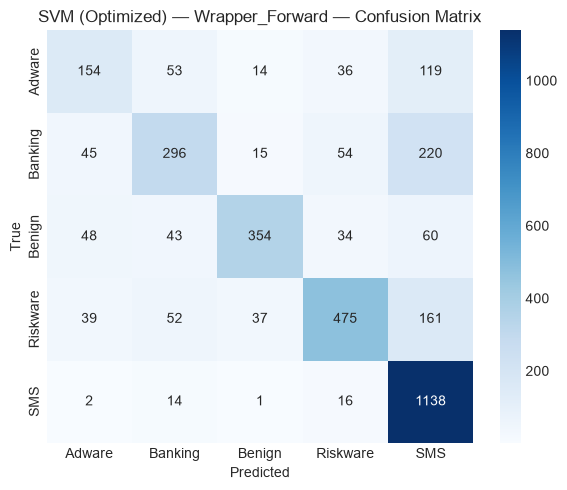


 GridSearchCV completed for selected features only!


In [19]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

def _make_svc_pipeline():
    return Pipeline([('clf', SVC( random_state=42))])

param_grid_svm =param_grid = {'clf__C': [0.1, 1, 10, 100, 1000], 
			'clf__gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
			'clf__kernel': ['rbf']}
sCV_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=1000)

print(" Starting SVM + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    
    #
    if fs_name == 'Full_Features':
        continue
        
    print(f"{'='*60}\n Testing SVM (GridSearchCV) on Feature Set: {fs_name}\n{'='*60}")

  
    grid_search = GridSearchCV(
        estimator=_make_svc_pipeline(),
        param_grid=param_grid_svm,
        cv=sCV_svm,
        scoring='f1_weighted',
        n_jobs=-1
    )

    start_time = time.time()
    grid_search.fit(X_tr, y_train)
    train_time = time.time() - start_time

    print(f" Training Time: {train_time:.2f}s |  Best Params: {grid_search.best_params_}")
    start_pred = time.time()   
    y_pred = grid_search.best_estimator_.predict(X_te)
    pred_time = time.time() - start_pred

    label = f'SVM (Optimized) — {fs_name}'
    print(f"\n predict Time: {pred_time:.2f} seconds")
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                ,'Best_Params': grid_search.best_params_}

print("\n GridSearchCV completed for selected features only!")


 Starting MLP + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...

 Testing MLP (GridSearchCV) on Feature Set: Filter_MI
 Training Time: 38.64s |  Best Params: {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (128, 64, 32), 'clf__learning_rate': 'constant', 'clf__learning_rate_init': 0.01, 'clf__solver': 'adam'}

 predict Time: 0.01 seconds

=== MLP (Optimized) — Filter_MI ===
Accuracy : 0.8267   Precision : 0.8259   Recall : 0.8267   Weighted F1 : 0.8244   Macro F1: 0.7942
              precision    recall  f1-score   support

      Adware       0.67      0.65      0.66       376
     Banking       0.77      0.77      0.77       630
      Benign       0.87      0.73      0.79       539
    Riskware       0.85      0.81      0.83       764
         SMS       0.87      0.97      0.92      1171

    accuracy                           0.83      3480
   macro avg       0.81      0.79      0.79      3480
weighted avg       0.83      0.83      0.82      3480



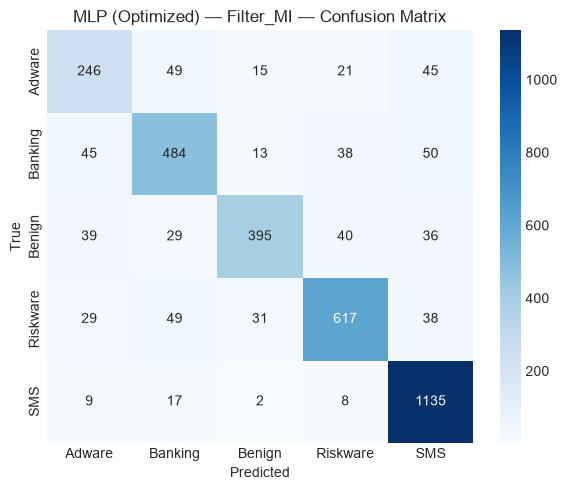

 Testing MLP (GridSearchCV) on Feature Set: Filter_Chi2
 Training Time: 39.86s |  Best Params: {'clf__activation': 'relu', 'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (128, 64, 32), 'clf__learning_rate': 'constant', 'clf__learning_rate_init': 0.01, 'clf__solver': 'adam'}

 predict Time: 0.01 seconds

=== MLP (Optimized) — Filter_Chi2 ===
Accuracy : 0.7592   Precision : 0.7757   Recall : 0.7592   Weighted F1 : 0.7533   Macro F1: 0.7369
              precision    recall  f1-score   support

      Adware       0.69      0.65      0.67       376
     Banking       0.74      0.54      0.62       630
      Benign       0.91      0.71      0.80       539
    Riskware       0.87      0.70      0.78       764
         SMS       0.70      0.97      0.81      1171

    accuracy                           0.76      3480
   macro avg       0.78      0.72      0.74      3480
weighted avg       0.78      0.76      0.75      3480



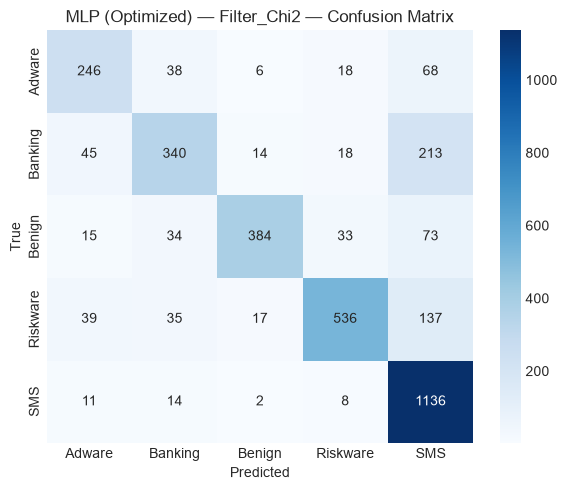

 Testing MLP (GridSearchCV) on Feature Set: Wrapper_RFECV
 Training Time: 57.76s |  Best Params: {'clf__activation': 'relu', 'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (128, 64, 32), 'clf__learning_rate': 'constant', 'clf__learning_rate_init': 0.01, 'clf__solver': 'adam'}

 predict Time: 0.01 seconds

=== MLP (Optimized) — Wrapper_RFECV ===
Accuracy : 0.9023   Precision : 0.9015   Recall : 0.9023   Weighted F1 : 0.9016   Macro F1: 0.8823
              precision    recall  f1-score   support

      Adware       0.86      0.77      0.82       376
     Banking       0.88      0.88      0.88       630
      Benign       0.86      0.87      0.86       539
    Riskware       0.88      0.88      0.88       764
         SMS       0.96      0.98      0.97      1171

    accuracy                           0.90      3480
   macro avg       0.89      0.88      0.88      3480
weighted avg       0.90      0.90      0.90      3480



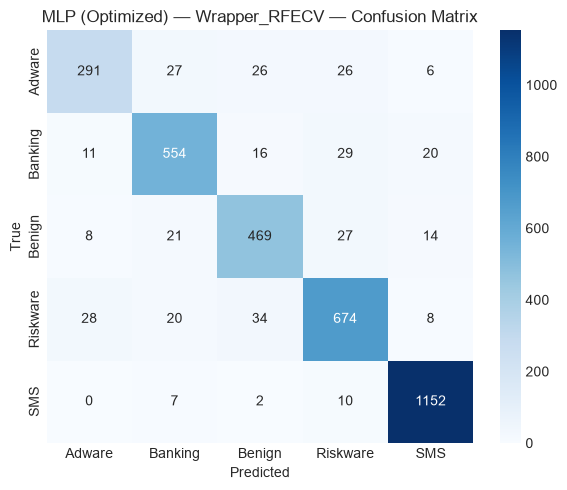

 Testing MLP (GridSearchCV) on Feature Set: Wrapper_Forward
 Training Time: 35.38s |  Best Params: {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (128, 64, 32), 'clf__learning_rate': 'constant', 'clf__learning_rate_init': 0.01, 'clf__solver': 'adam'}

 predict Time: 0.01 seconds

=== MLP (Optimized) — Wrapper_Forward ===
Accuracy : 0.7598   Precision : 0.7617   Recall : 0.7598   Weighted F1 : 0.7568   Macro F1: 0.7223
              precision    recall  f1-score   support

      Adware       0.57      0.57      0.57       376
     Banking       0.64      0.64      0.64       630
      Benign       0.85      0.72      0.78       539
    Riskware       0.83      0.70      0.76       764
         SMS       0.81      0.95      0.87      1171

    accuracy                           0.76      3480
   macro avg       0.74      0.71      0.72      3480
weighted avg       0.76      0.76      0.76      3480



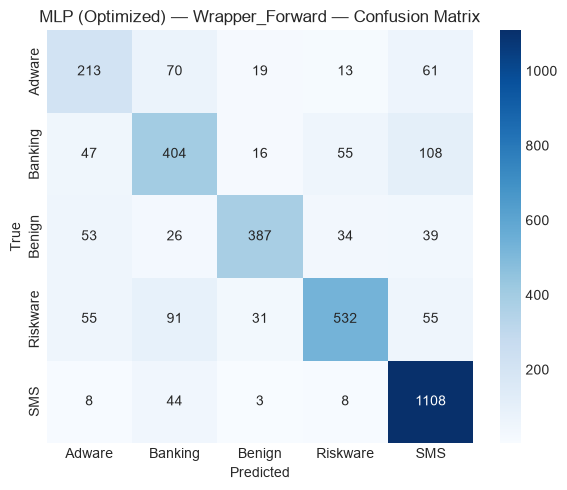


 GridSearchCV completed for selected features only (MLP)!


In [20]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

def _make_mlp_pipeline():
    return Pipeline([('clf', MLPClassifier(
        activation='relu', solver='adam', batch_size=256,
        max_iter=50, early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=5, random_state=42))])

param_grid_mlp = param_grid_mlp_maldroid = {
    'clf__hidden_layer_sizes': [(100,), (64, 32), (128, 64, 32)],
    'clf__activation': ['relu'],
    'clf__solver': ['adam', 'sgd'],
    'clf__alpha': [0.0001, 0.001, 0.01],
    'clf__learning_rate': ['constant', 'adaptive'],
    'clf__learning_rate_init': [0.001, 0.01]
}
sCV_mlp = StratifiedKFold(n_splits=5, shuffle=True, random_state=1000)  
print(" Starting MLP + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    
    if fs_name == 'Full_Features':
        continue
        
    print(f"{'='*60}\n Testing MLP (GridSearchCV) on Feature Set: {fs_name}\n{'='*60}")

    grid_search = GridSearchCV(
        estimator=_make_mlp_pipeline(),
        param_grid=param_grid_mlp,
        cv=sCV_mlp,
        scoring='f1_weighted',
        n_jobs=-1  
    )

    start_time = time.time()
    grid_search.fit(X_tr, y_train)
    train_time = time.time() - start_time

    print(f" Training Time: {train_time:.2f}s |  Best Params: {grid_search.best_params_}")
    start_pred = time.time()   
    y_pred = grid_search.best_estimator_.predict(X_te)
    pred_time = time.time() - start_pred

   
    print(f"\n predict Time: {pred_time:.2f} seconds")
    label = f'MLP (Optimized) — {fs_name}'
    
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                ,'Best_Params': grid_search.best_params_}

print("\n GridSearchCV completed for selected features only (MLP)!")

 Starting XGBoost + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...

 Testing XGBoost on Feature Set: Filter_MI (Features Count: 30)
 Training Time: 123.96 seconds
 Best Hyperparameters found: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 100, 'clf__subsample': 0.8}

 predict Time: 0.01 seconds

=== XGBoost (Optimized) — Filter_MI ===
Accuracy : 0.9218   Precision : 0.9223   Recall : 0.9218   Weighted F1 : 0.9219   Macro F1: 0.9053
              precision    recall  f1-score   support

      Adware       0.84      0.88      0.86       376
     Banking       0.91      0.90      0.90       630
      Benign       0.86      0.88      0.87       539
    Riskware       0.93      0.90      0.91       764
         SMS       0.97      0.99      0.98      1171

    accuracy                           0.92      3480
   macro avg       0.90      0.91      0.91      3480
weighted avg       0.92      0.92      0.9

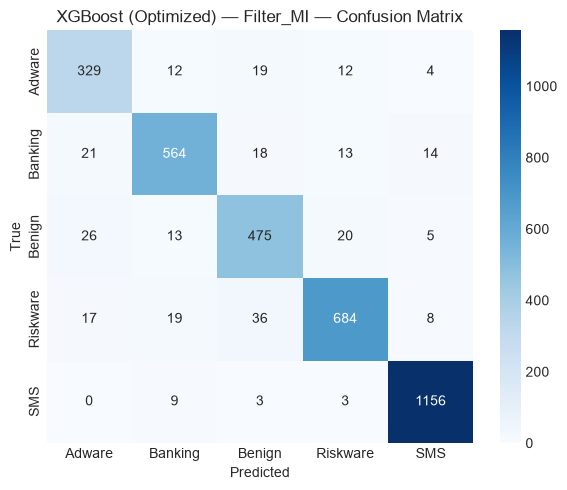

 Testing XGBoost on Feature Set: Filter_Chi2 (Features Count: 30)
 Training Time: 28.33 seconds
 Best Hyperparameters found: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 100, 'clf__subsample': 0.8}

 predict Time: 0.01 seconds

=== XGBoost (Optimized) — Filter_Chi2 ===
Accuracy : 0.8575   Precision : 0.8576   Recall : 0.8575   Weighted F1 : 0.8561   Macro F1: 0.8370
              precision    recall  f1-score   support

      Adware       0.82      0.74      0.78       376
     Banking       0.77      0.82      0.79       630
      Benign       0.87      0.81      0.84       539
    Riskware       0.88      0.81      0.85       764
         SMS       0.89      0.97      0.93      1171

    accuracy                           0.86      3480
   macro avg       0.85      0.83      0.84      3480
weighted avg       0.86      0.86      0.86      3480



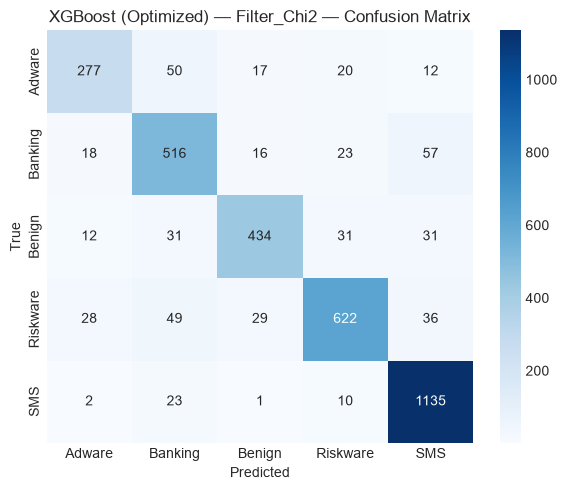

 Testing XGBoost on Feature Set: Wrapper_RFECV (Features Count: 92)
 Training Time: 124.82 seconds
 Best Hyperparameters found: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 100, 'clf__subsample': 0.8}

 predict Time: 0.01 seconds

=== XGBoost (Optimized) — Wrapper_RFECV ===
Accuracy : 0.9425   Precision : 0.9428   Recall : 0.9425   Weighted F1 : 0.9425   Macro F1: 0.9319
              precision    recall  f1-score   support

      Adware       0.89      0.91      0.90       376
     Banking       0.95      0.91      0.93       630
      Benign       0.91      0.94      0.92       539
    Riskware       0.94      0.92      0.93       764
         SMS       0.98      0.99      0.98      1171

    accuracy                           0.94      3480
   macro avg       0.93      0.93      0.93      3480
weighted avg       0.94      0.94      0.94      3480



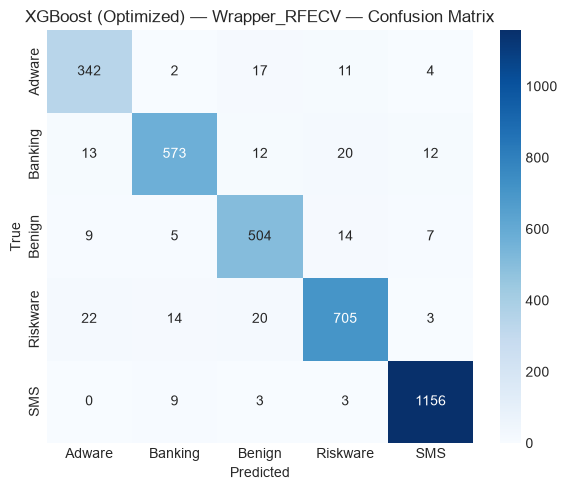

 Testing XGBoost on Feature Set: Wrapper_Forward (Features Count: 20)
 Training Time: 44.64 seconds
 Best Hyperparameters found: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 100, 'clf__subsample': 0.8}

 predict Time: 0.01 seconds

=== XGBoost (Optimized) — Wrapper_Forward ===
Accuracy : 0.9259   Precision : 0.9263   Recall : 0.9259   Weighted F1 : 0.9259   Macro F1: 0.9114
              precision    recall  f1-score   support

      Adware       0.84      0.88      0.86       376
     Banking       0.93      0.89      0.91       630
      Benign       0.89      0.90      0.89       539
    Riskware       0.92      0.90      0.91       764
         SMS       0.97      0.99      0.98      1171

    accuracy                           0.93      3480
   macro avg       0.91      0.91      0.91      3480
weighted avg       0.93      0.93      0.93      3480



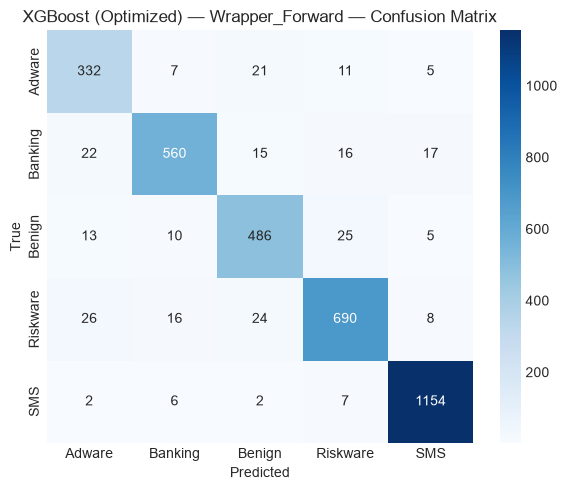


 All XGBoost models optimized and evaluated successfully on selected features!


In [21]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import xgboost as xgb
import time

param_grid_xgb = param_grid_xgb_maldroid = {
    'clf__n_estimators': [100, 300],              
    'clf__learning_rate': [0.05, 0.1, 0.2],       
    'clf__max_depth': [6, 10],                    
    'clf__min_child_weight': [1, 3],              
    'clf__subsample': [0.8, 1.0],                 
    'clf__colsample_bytree': [0.8, 1.0]           
}
sCV = StratifiedKFold(n_splits=5, shuffle=True, random_state=1000)

print(" Starting XGBoost + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    
    if fs_name == 'Full_Features':
        continue
        
    print(f"{'='*60}")
    print(f" Testing XGBoost on Feature Set: {fs_name} (Features Count: {X_tr.shape[1]})")
    print(f"{'='*60}")
    
    xgb_clf = xgb.XGBClassifier(verbosity=0, random_state=42, n_jobs=-1)
    
    grid_search = GridSearchCV(
        estimator=xgb_clf,
        param_grid=param_grid_xgb,
        cv=sCV,
        scoring='f1_weighted',
        n_jobs=-1
    )
    
    start_time = time.time()
    grid_search.fit(X_tr, y_train)
    train_time = time.time() - start_time
    
    print(f" Training Time: {train_time:.2f} seconds")
    print(f" Best Hyperparameters found: {grid_search.best_params_}")
    
    best_model = grid_search.best_estimator_
    start_pred = time.time()   
    y_pred = best_model.predict(X_te)
    pred_time = time.time() - start_pred

   
    print(f"\n predict Time: {pred_time:.2f} seconds")
    label = f'XGBoost (Optimized) — {fs_name}'
    
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                ,'Best_Params': grid_search.best_params_}

print("\n All XGBoost models optimized and evaluated successfully on selected features!")



                            Algorithm Accuracy Weighted F1 Macro F1 Train Time Predict Time
   XGBoost (Baseline) — Full_Features   0.9457      0.9456   0.9353      2.32s        0.03s
   XGBoost (Baseline) — Wrapper_RFECV   0.9425      0.9425   0.9319      0.66s        0.00s
  XGBoost (Optimized) — Wrapper_RFECV   0.9425      0.9425   0.9319    124.82s        0.01s
XGBoost (Optimized) — Wrapper_Forward   0.9259      0.9259   0.9114     44.64s        0.01s
 XGBoost (Baseline) — Wrapper_Forward   0.9259      0.9259   0.9114      0.36s        0.00s
       XGBoost (Baseline) — Filter_MI   0.9218      0.9219   0.9053      0.65s        0.01s
      XGBoost (Optimized) — Filter_MI   0.9218      0.9219   0.9053    123.96s        0.01s
      MLP (Optimized) — Wrapper_RFECV   0.9023      0.9016   0.8823     57.76s        0.01s
      SVM (Optimized) — Wrapper_RFECV   0.8632      0.8621   0.8417     73.29s        0.73s
                  MLP — Full_Features   0.8618      0.8598   0.8368      5.69s

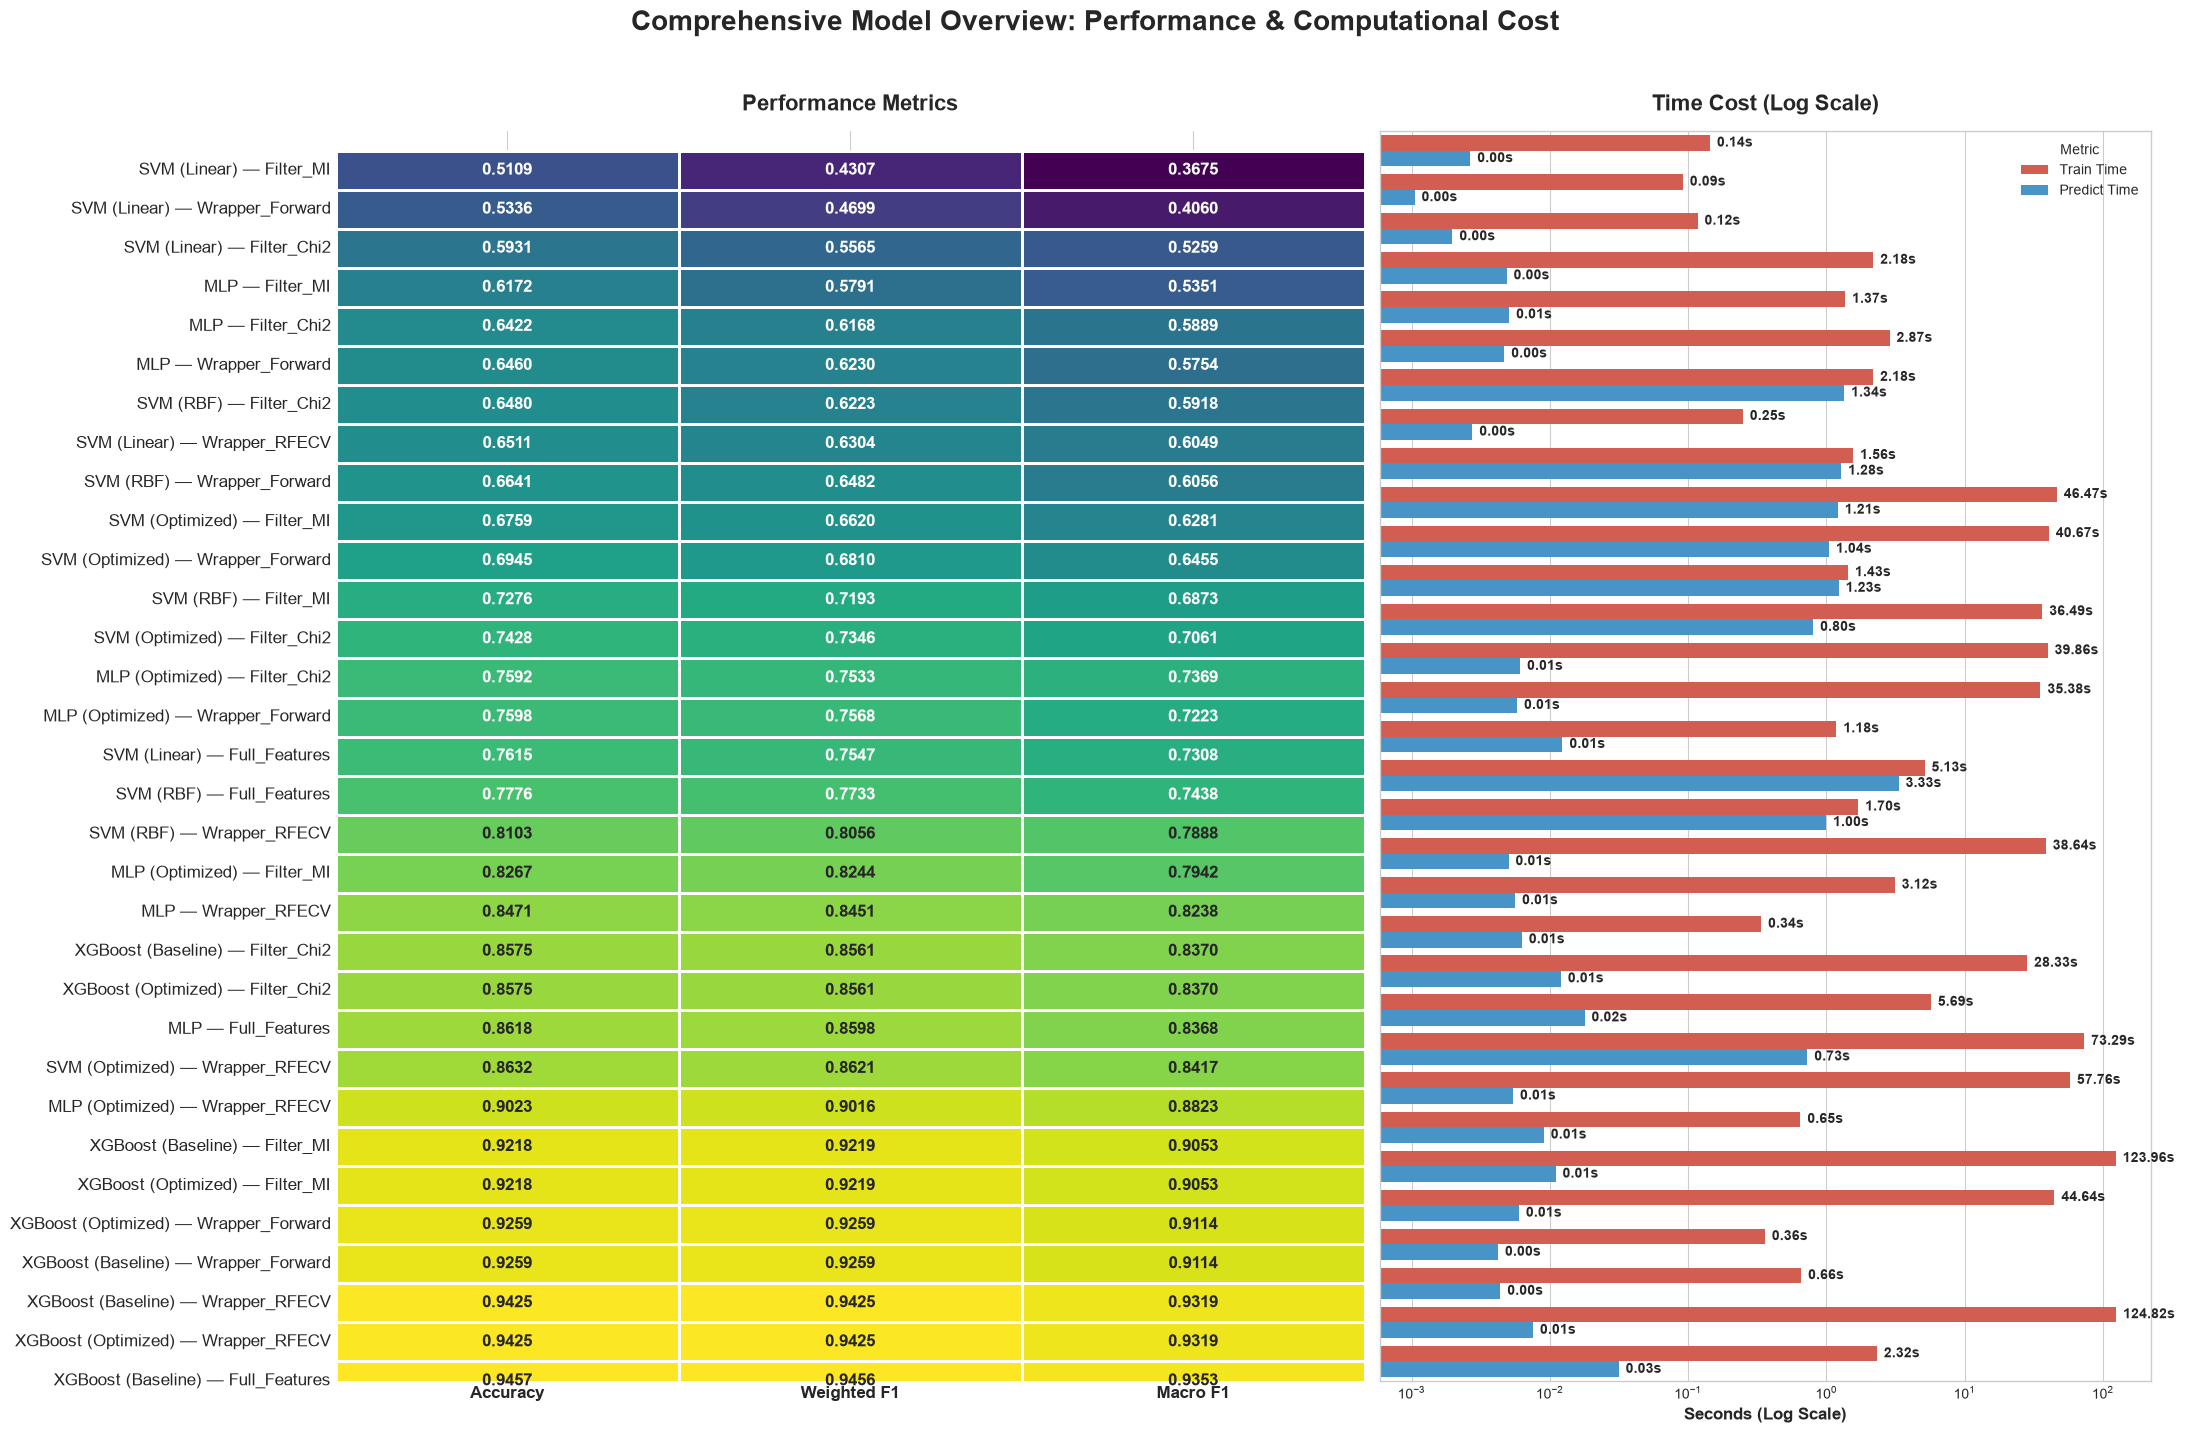

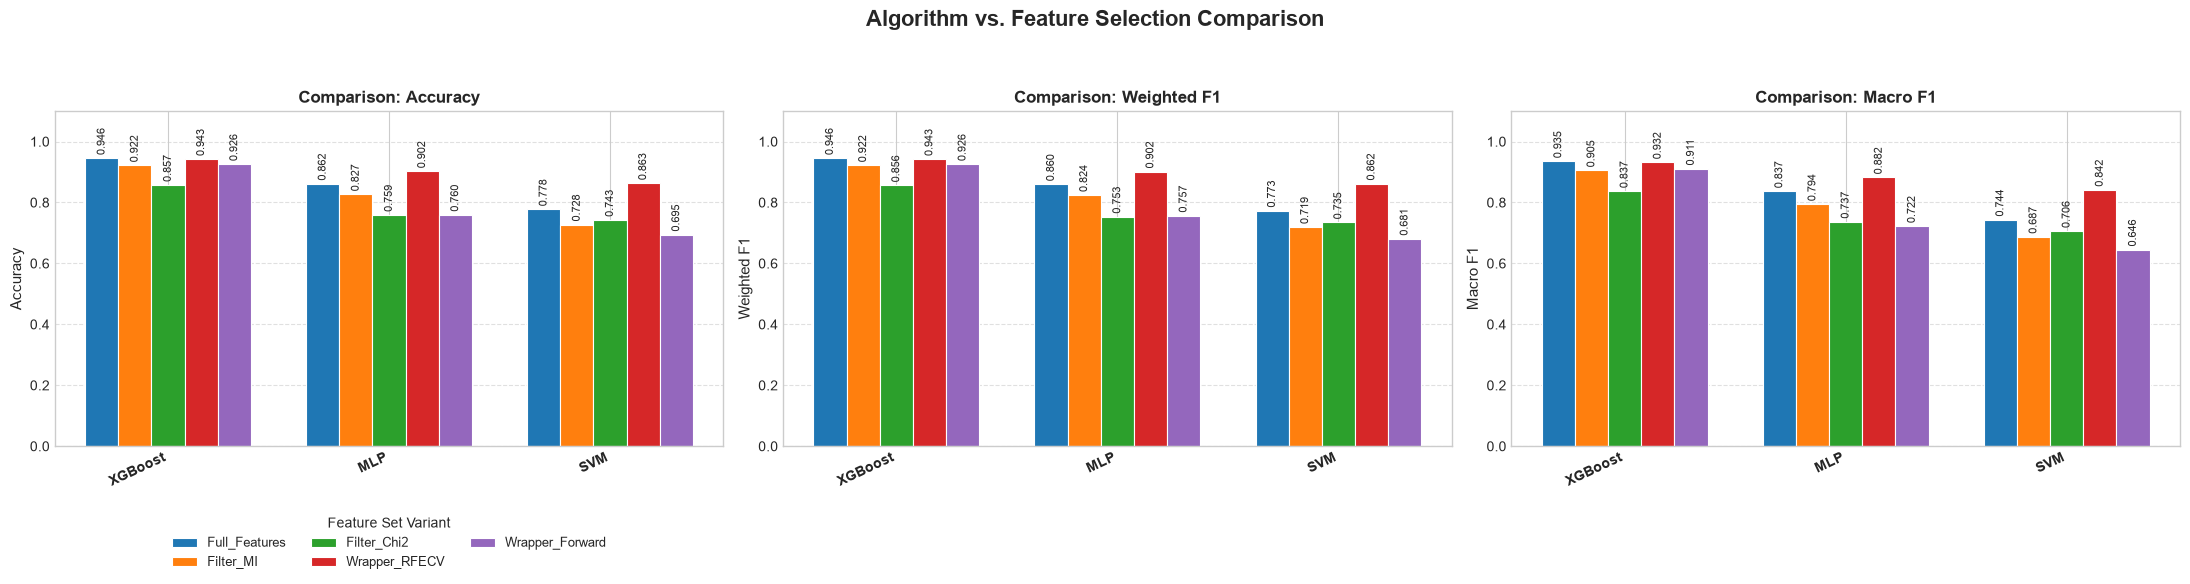



 Filter Impact vs. Full-Features Baseline (Positive = Improvement) 

Model Family     Feature Set Δ Accuracy Δ Macro F1 Train Time Predict Time
     XGBoost       Filter_MI    -0.0239    -0.0300      0.65s      0.0090s
     XGBoost     Filter_Chi2    -0.0882    -0.0983      0.34s      0.0063s
     XGBoost   Wrapper_RFECV    -0.0032    -0.0034      0.66s      0.0044s
     XGBoost Wrapper_Forward    -0.0198    -0.0240     44.64s      0.0060s
         MLP       Filter_MI    -0.0351    -0.0425     38.64s      0.0050s
         MLP     Filter_Chi2    -0.1026    -0.0999     39.86s      0.0061s
         MLP   Wrapper_RFECV    +0.0405    +0.0456     57.76s      0.0054s
         MLP Wrapper_Forward    -0.1020    -0.1144     35.38s      0.0058s
         SVM       Filter_MI    -0.0500    -0.0565      1.43s      1.2288s
         SVM     Filter_Chi2    -0.0348    -0.0377     36.49s      0.8029s
         SVM   Wrapper_RFECV    +0.0856    +0.0979     73.29s      0.7280s
         SVM Wrapper_Forward 

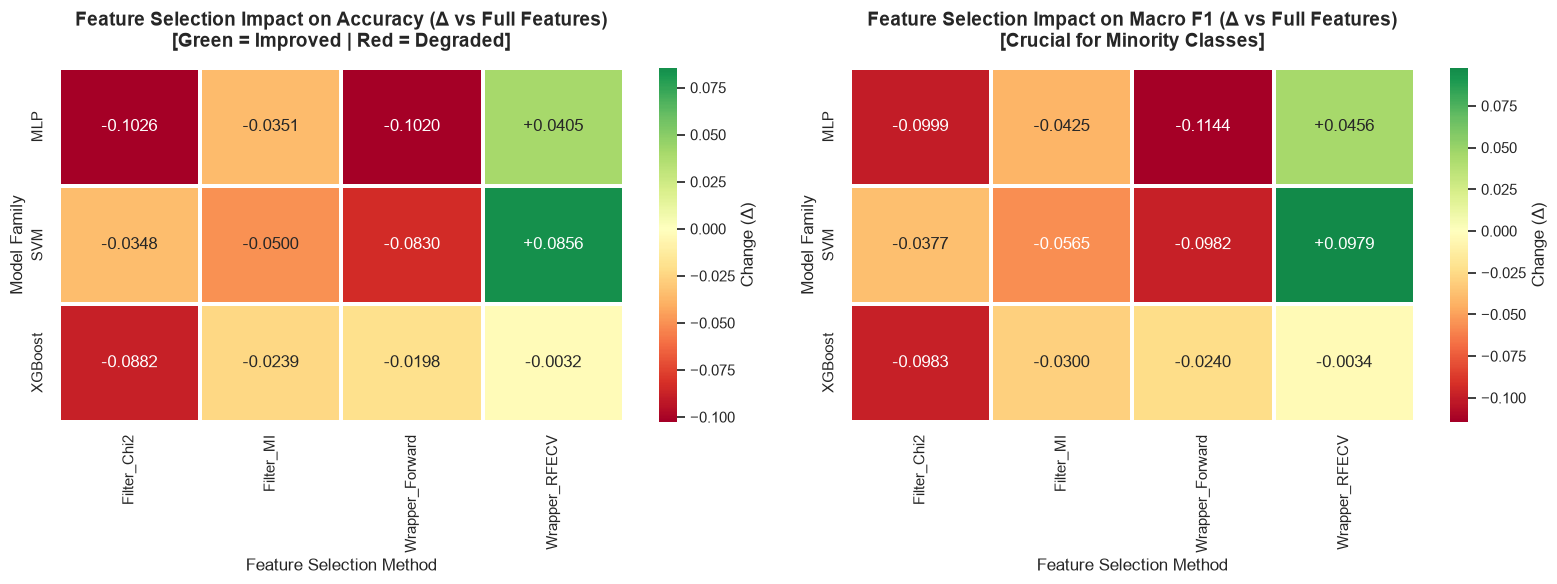

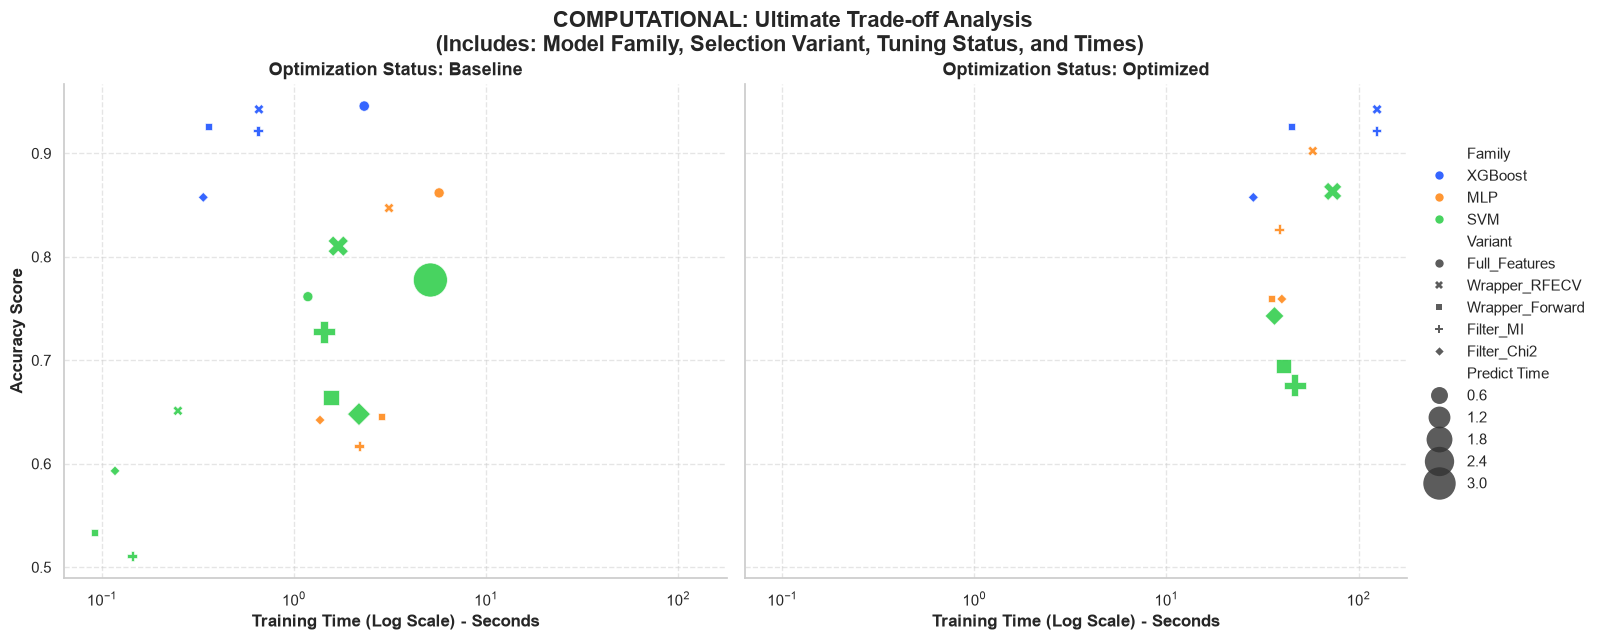

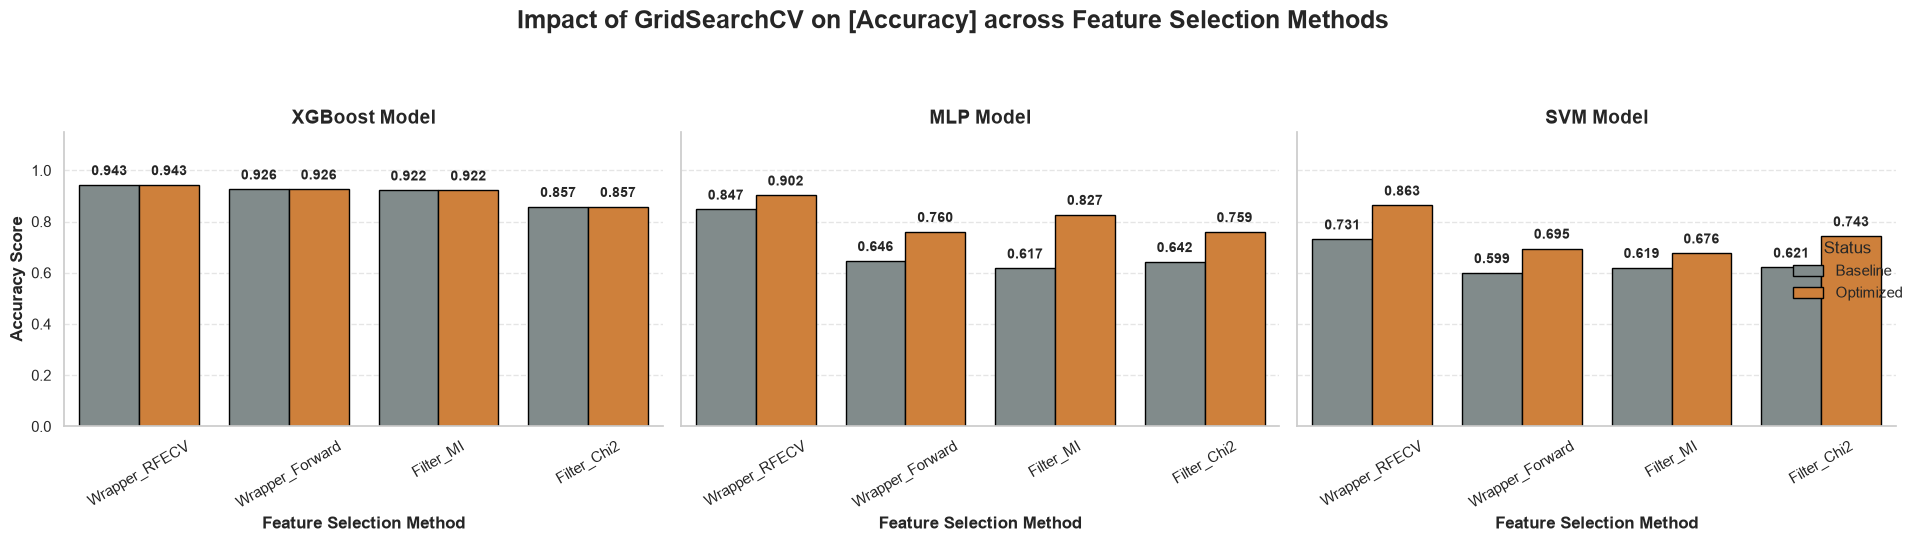

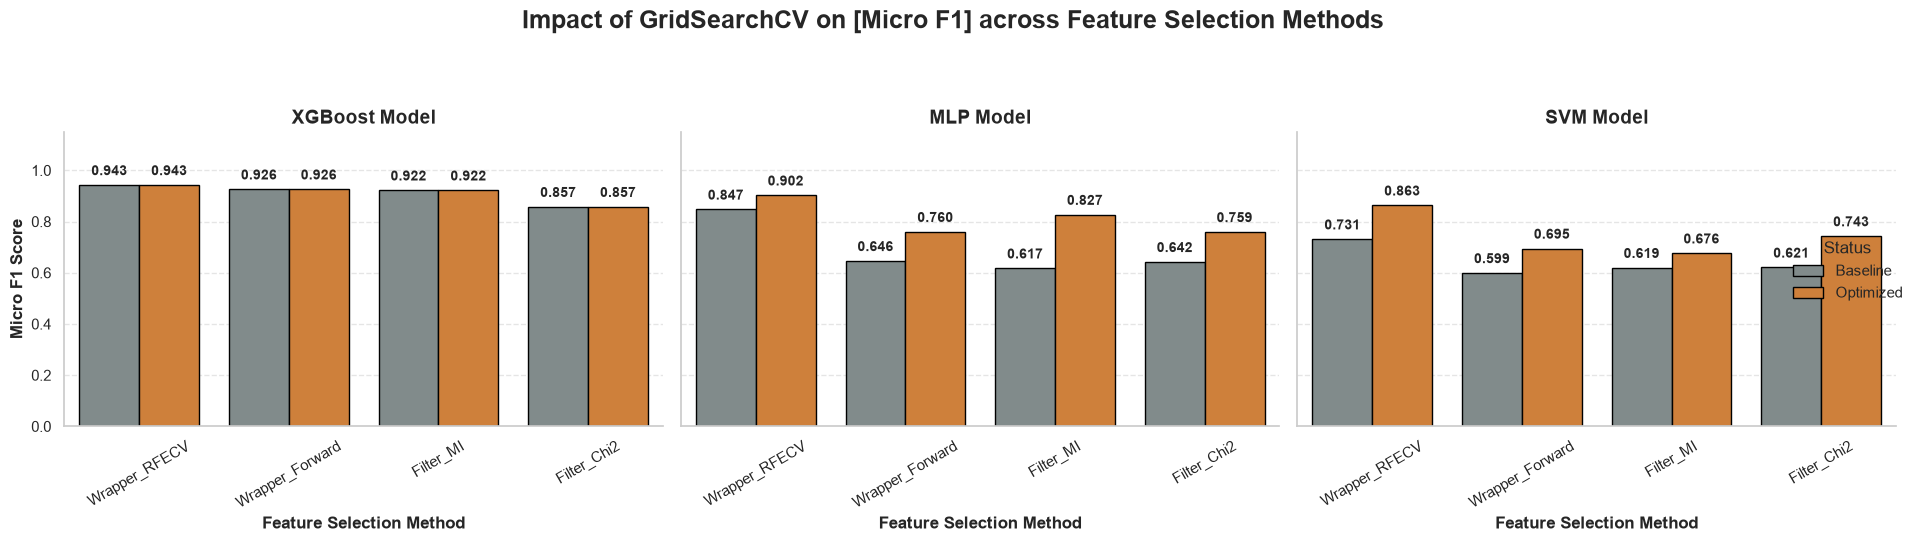

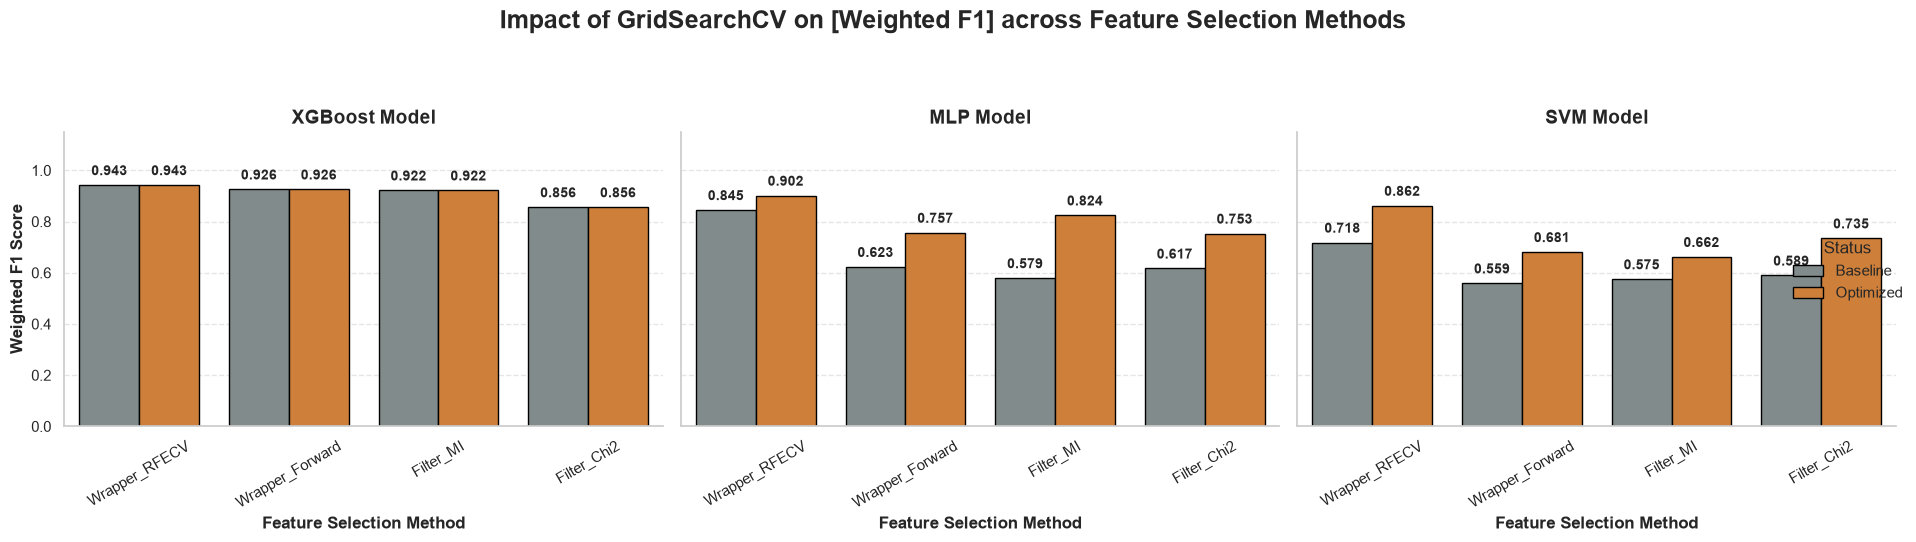

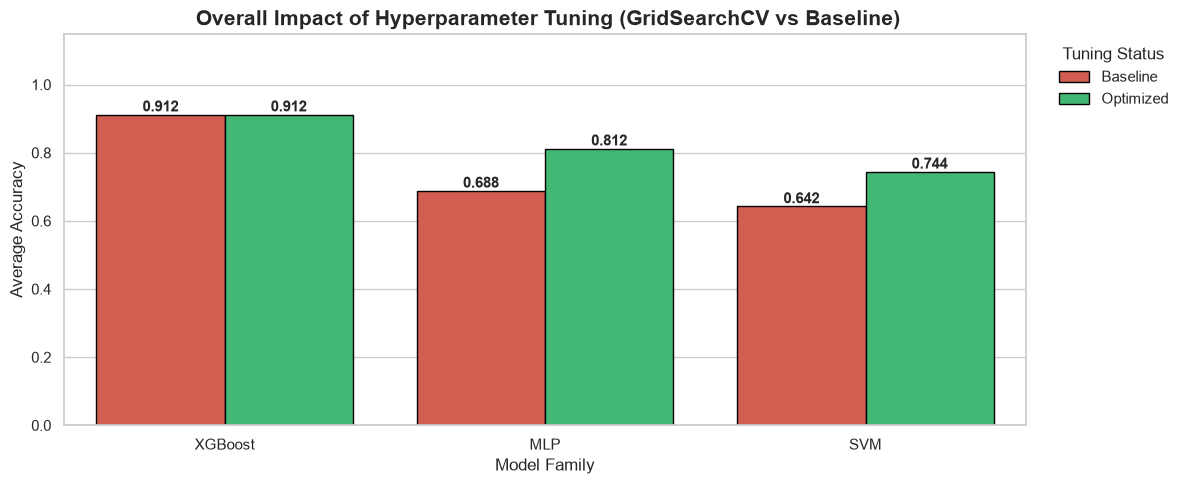

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

def _safe_float(v):
    try:
        val = float(v)
        return val if not np.isnan(val) else float('nan')
    except (TypeError, ValueError):
        return float('nan')

_rows = []
for name, metrics in RESULTS.items():
    train_time = (metrics.get('Train Time (s)') or 
                  metrics.get('Train Time') or 
                  metrics.get('Time') or 0)
                  
    pred_time = (metrics.get('Predict Time (s)') or 
                 metrics.get('Predict Time') or 0)
        
    _rows.append({
        'Algorithm'   : name,
        'Accuracy'    : _safe_float(metrics.get('Accuracy')),
        'Weighted F1' : _safe_float(metrics.get('Weighted F1', metrics.get('F1'))),
        'Macro F1'    : _safe_float(metrics.get('Macro F1')),
        'Train Time'  : _safe_float(train_time),
        'Predict Time': _safe_float(pred_time)
    })

results_df = pd.DataFrame(_rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)

def _parse(name):
    clean_name = str(name).replace('===', '').replace('', '').strip()
    
    variant = 'Full_Features'
    for v in ['Filter_MI', 'Filter_Chi2', 'Wrapper_RFECV', 'Wrapper_Forward']:
        if v.lower() in clean_name.lower():
            variant = v
            break
            
    if variant == 'Full_Features':
        status = 'Baseline'
    else:
        
        status = 'Optimized' if 'Optimized' in clean_name else 'Baseline'
    
    if 'SVM' in clean_name: family = 'SVM'
    elif 'MLP' in clean_name: family = 'MLP'
    elif 'XGBoost' in clean_name: family = 'XGBoost'
    else: family = clean_name.split('—')[0].split('-')[0].strip()
        
    return family, status, variant

parsed_data = results_df['Algorithm'].apply(lambda n: pd.Series(_parse(n)))
results_df['Family'] = parsed_data[0]
results_df['Status'] = parsed_data[1]
results_df['Variant'] = parsed_data[2]

results_df = results_df[~((results_df['Variant'] == 'Full_Features') & 
                          (results_df['Algorithm'].str.contains('Optimized', case=False, na=False)))].reset_index(drop=True)

pretty = results_df.copy()
for col in ['Accuracy', 'Weighted F1', 'Macro F1']:
    pretty[col] = pretty[col].map(lambda x: f'{x:.4f}' if not pd.isna(x) else 'N/A')
for col in ['Train Time', 'Predict Time']:
    pretty[col] = pretty[col].map(lambda x: f'{x:.2f}s' if not pd.isna(x) and x > 0 else 'N/A')

print(''*95)

print(''*95)
print(pretty[['Algorithm', 'Accuracy', 'Weighted F1', 'Macro F1', 'Train Time', 'Predict Time']].to_string(index=False))
print('\n')

clean_df = results_df.dropna(subset=['Accuracy']).copy()
df_comprehensive = clean_df.sort_values('Accuracy', ascending=True).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 14), gridspec_kw={'width_ratios': [2, 1.5]}, sharey=True)

metrics_cols = ['Accuracy', 'Weighted F1', 'Macro F1']
metrics_df = df_comprehensive.set_index('Algorithm')[metrics_cols]

sns.heatmap(metrics_df, annot=True, fmt=".4f", cmap="viridis", cbar=False, 
            linewidths=1, linecolor='white', ax=ax1, annot_kws={"size": 12, "weight": "bold"})

ax1.set_title('Performance Metrics', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('')
ax1.tick_params(axis='y', labelsize=12, labelrotation=0)
ax1.tick_params(axis='x', labelsize=12)
plt.setp(ax1.get_xticklabels(), fontweight='bold')

time_df = df_comprehensive[['Algorithm', 'Train Time', 'Predict Time']].melt(id_vars='Algorithm', var_name='Metric', value_name='Time(s)')

sns.barplot(data=time_df, y='Algorithm', x='Time(s)', hue='Metric', ax=ax2, palette=['#e74c3c', '#3498db'])

ax2.set_xscale('log')
ax2.set_title('Time Cost (Log Scale)', fontsize=16, fontweight='bold', pad=15)
ax2.set_ylabel('')
ax2.set_xlabel('Seconds (Log Scale)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', left=False)

for p in ax2.patches:
    width = p.get_width()
    if width > 0 and not np.isnan(width):
        ax2.annotate(f"{width:.2f}s", 
                     (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=10, fontweight='bold',
                     xytext=(5, 0), textcoords='offset points')

plt.suptitle('Comprehensive Model Overview: Performance & Computational Cost', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

families = results_df['Family'].drop_duplicates().tolist()
variants = ['Full_Features', 'Filter_MI', 'Filter_Chi2', 'Wrapper_RFECV', 'Wrapper_Forward']
existing_variants = [v for v in variants if v in results_df['Variant'].values]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
variant_colors = dict(zip(existing_variants, colors[:len(existing_variants)]))

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
metrics_to_plot = ['Accuracy', 'Weighted F1', 'Macro F1']

for ax, metric in zip(axes, metrics_to_plot):
    x = np.arange(len(families))
    width = 0.15  
    
    for j, v in enumerate(existing_variants):
        vals = []
        for fam in families:
            sub = results_df[(results_df['Family'] == fam) & (results_df['Variant'] == v)]
            vals.append(sub[metric].iloc[0] if len(sub) else float('nan'))
        
        offset = (j - len(existing_variants)/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=v, color=variant_colors.get(v, '#333'), edgecolor='white', linewidth=0.8)
        
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
    
    ax.set_xticks(x)
    ax.set_xticklabels(families, rotation=25, ha='right', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_title(f'Comparison: {metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    if metric == 'Accuracy':
        ax.legend(title='Feature Set Variant', fontsize=9, loc='lower center', bbox_to_anchor=(0.5, -0.4), ncol=3)

plt.suptitle('Algorithm vs. Feature Selection Comparison', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

delta_rows = []
for fam in families:
    base = results_df[(results_df['Family'] == fam) & (results_df['Variant'] == 'Full_Features') & (results_df['Status'] == 'Baseline')]
    if not len(base):
        base = results_df[(results_df['Family'] == fam) & (results_df['Variant'] == 'Full_Features')]
    if not len(base): continue
    
    base_acc = base['Accuracy'].iloc[0]
    base_mac = base['Macro F1'].iloc[0]
    
    for v in existing_variants:
        if v == 'Full_Features': continue
        sub = results_df[(results_df['Family'] == fam) & (results_df['Variant'] == v)]
        if not len(sub): continue
        
        delta_rows.append({
            'Model Family': fam,
            'Feature Set': v,
            'Δ Accuracy': sub['Accuracy'].iloc[0] - base_acc,
            'Δ Macro F1': sub['Macro F1'].iloc[0] - base_mac,
            'Train Time': sub['Train Time'].iloc[0],      
            'Predict Time': sub['Predict Time'].iloc[0]   
        })

delta_df = pd.DataFrame(delta_rows)
print('\n' + ''*85)
print(' Filter Impact vs. Full-Features Baseline (Positive = Improvement) ')
print(''*85)
if not delta_df.empty:
    print(delta_df.to_string(index=False, formatters={
        'Δ Accuracy': '{:+.4f}'.format, 
        'Δ Macro F1': '{:+.4f}'.format,
        'Train Time': '{:.2f}s'.format,
        'Predict Time': '{:.4f}s'.format
    }))

    print("\n" + ""*40)
    print(""*40 + "\n")
    
    sns.set_theme(style="darkgrid", palette="deep")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    pivot_acc_delta = delta_df.pivot(index='Model Family', columns='Feature Set', values='Δ Accuracy')
    pivot_mac_delta = delta_df.pivot(index='Model Family', columns='Feature Set', values='Δ Macro F1')
    
    sns.heatmap(pivot_acc_delta, annot=True, cmap='RdYlGn', center=0, fmt='+.4f', 
                linewidths=1.5, linecolor='white', cbar_kws={'label': 'Change (Δ)'}, ax=axes[0])
    axes[0].set_title('Feature Selection Impact on Accuracy (Δ vs Full Features)\n[Green = Improved | Red = Degraded]', 
                      fontweight='bold', fontsize=14, pad=15)
    axes[0].set_xlabel('Feature Selection Method', fontsize=12)
    axes[0].set_ylabel('Model Family', fontsize=12)
    
    sns.heatmap(pivot_mac_delta, annot=True, cmap='RdYlGn', center=0, fmt='+.4f', 
                linewidths=1.5, linecolor='white', cbar_kws={'label': 'Change (Δ)'}, ax=axes[1])
    axes[1].set_title('Feature Selection Impact on Macro F1 (Δ vs Full Features)\n[Crucial for Minority Classes]', 
                      fontweight='bold', fontsize=14, pad=15)
    axes[1].set_xlabel('Feature Selection Method', fontsize=12)
    axes[1].set_ylabel('Model Family', fontsize=12)
    
    plt.tight_layout()
    plt.show()

sns.set_theme(style="whitegrid")
clean_df = results_df.dropna(subset=['Accuracy']).copy()

def get_micro_f1(algo_name):
    return RESULTS.get(algo_name, {}).get('Micro F1', RESULTS.get(algo_name, {}).get('Accuracy', np.nan))
clean_df['Micro F1'] = clean_df['Algorithm'].apply(get_micro_f1)

def categorize_fs(variant):
    if 'Filter' in variant: return 'Filter Methods'
    elif 'Wrapper' in variant: return 'Wrapper Methods'
    return 'Full Features'
clean_df['FS_Type'] = clean_df['Variant'].apply(categorize_fs)

print("\n" + ""*40)
print(""*40 + "\n")

g = sns.relplot(
    data=clean_df,
    x='Train Time',
    y='Accuracy',
    col='Status',        
    hue='Family',        
    style='Variant',     
    size='Predict Time', 
    sizes=(50, 600),     
    alpha=0.8,
    palette='bright',
    height=6,
    aspect=1.2,
    kind='scatter'
)

g.fig.suptitle(' COMPUTATIONAL: Ultimate Trade-off Analysis\n(Includes: Model Family, Selection Variant, Tuning Status, and Times)', 
               fontweight='bold', fontsize=16, y=1.06)
g.set_axis_labels('Training Time (Log Scale) - Seconds', 'Accuracy Score', fontweight='bold')
g.set_titles("Optimization Status: {col_name}", fontweight='bold', size=13)

for ax in g.axes.flat:
    ax.set_xscale('log')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

selection_only_df = clean_df[clean_df['Variant'] != 'Full_Features'].copy()

print("\n" + ""*50)
print(""*50 + "\n")

target_metrics = ['Accuracy', 'Micro F1', 'Weighted F1']
status_colors = {'Baseline': '#7f8c8d', 'Optimized': '#e67e22'}

for metric in target_metrics:
    g = sns.catplot(
        data=selection_only_df, 
        x='Variant',          
        y=metric,             
        hue='Status',         
        col='Family',         
        kind='bar', 
        palette=status_colors,
        height=5, 
        aspect=1.2,
        edgecolor='black',
        ci=None
    )
    
    g.fig.suptitle(f'Impact of GridSearchCV on [{metric}] across Feature Selection Methods', 
                   fontsize=18, fontweight='bold', y=1.08)
    g.set_axis_labels("Feature Selection Method", f"{metric} Score", fontsize=12, fontweight='bold')
    g.set_titles("{col_name} Model", size=14, fontweight='bold')
    
    for ax in g.axes.flat:
        ax.set_ylim(0, 1.15) 
        ax.tick_params(axis='x', rotation=30) 
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        for p in ax.patches:
            height = p.get_height()
            if height > 0 and not np.isnan(height):
                ax.annotate(f"{height:.3f}", 
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', fontsize=10, rotation=0, 
                            xytext=(0, 5), textcoords='offset points', fontweight='bold')

    plt.tight_layout()
    plt.show()

print("\n" + ""*40)
print(""*40 + "\n")

opt_vs_base = clean_df[clean_df['Variant'] != 'Full_Features'].copy()

if not opt_vs_base.empty:
    plt.figure(figsize=(12, 5))
    sns.barplot(data=opt_vs_base, x='Family', y='Accuracy', hue='Status', ci=None, palette=['#e74c3c', '#2ecc71'], edgecolor='black')
    plt.title(' Overall Impact of Hyperparameter Tuning (GridSearchCV vs Baseline)', fontweight='bold', fontsize=15)
    plt.ylabel('Average Accuracy', fontsize=12)
    plt.xlabel('Model Family', fontsize=12)
    plt.ylim(0, 1.15)
    
    ax = plt.gca()
    for p in ax.patches:
        height = p.get_height()
        if height > 0 and not np.isnan(height):
            ax.annotate(f"{height:.3f}", (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=11, fontweight='bold')
            
    plt.legend(title='Tuning Status', bbox_to_anchor=(1.02, 1), loc=2)
    plt.tight_layout()
    plt.show()

In [24]:
results_df['Dataset'] = 'CIC-MalDroid20'
results_df.to_csv('CIC_MalDroid_Results0.3minmax.csv', index=False)
